<a href="https://colab.research.google.com/github/diem2701/NH-M-7---T-I-7/blob/main/NguyenThiNgocDiem_2321003579_Ph%C3%A2n%20t%C3%ADch%20h%C3%A0nh%20vi%20giao%20d%E1%BB%8Bch%20kh%C3%A1ch%20h%C3%A0ng.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PHÂN TÍCH HÀNH VI GIAO DỊCH VÀ DỰ BÁO SINH LỢI KHÁCH HÀNG BẰNG HỌC MÁY TẠI NGÂN HÀNG THƯƠNG MẠI

#CHƯƠNG 2: KẾT QUẢ NGHIÊN CỨU VÀ THẢO LUẬN

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from scipy import stats

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

##2.1. Tiền xử lý và mô tả dữ liệu

###2.1.1. Tiền xử lý dữ liệu

In [ ]:
# 1. Đọc dữ liệu
df = pd.read_csv('Banking_Transactional_Dataset.csv')
print(f"Kích thước dữ liệu: {df.shape}")
df.head()

Kích thước dữ liệu: (20000, 19)


,TransactionID,CustomerID,TransactionDate,TransactionType,Amount,ProductCategory,ProductSubcategory,BranchCity,BranchLat,BranchLong,Channel,Currency,CreditCardFees,InsuranceFees,LatePaymentAmount,CustomerScore,MonthlyIncome,CustomerSegment,RecommendedOffer
0,1,8270,1/29/2025 0:00,Card Payment,6980.185223,Checking Account,Gold,Seville,37.3891,-5.9845,Branch,EUR,0.0,0.00,0.0,839,5767.68,Middle Income Segment,Mid-tier Savings Booster
1,2,1860,2/10/2023 0:00,Deposit,10786.371850,Mortgage,Gold,Murcia,37.9847,-1.1287,Branch,EUR,0.0,0.00,0.0,683,2441.00,Low Income Segment,Financial Literacy Program Access
2,3,6390,3/7/2024 0:00,Transfer,3982.761111,Loan,Platinum,Malaga,36.7213,-4.4214,ATM,EUR,0.0,92.46,0.0,500,9957.08,High Income Segment,Premium Investment Services
3,4,6191,7/4/2023 0:00,Withdrawal,12408.644140,Mortgage,Standard,Seville,37.3891,-5.9845,ATM,EUR,0.0,0.00,0.0,392,1545.80,Low Income Segment,Financial Literacy Program Access
4,5,6734,2/5/2025 0:00,Fee,1868.260998,Checking Account,Platinum,Murcia,37.9847,-1.1287,Mobile,USD,0.0,0.00,0.0,368,5825.27,Middle Income Segment,Mid-tier Savings Booster


In [ ]:
# Chuyển đổi TransactionDate sang datetime
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], format="%m/%d/%Y %H:%M")

# Trích xuất các thành phần thời gian
df["Year"] = df["TransactionDate"].dt.year
df["Month"] = df["TransactionDate"].dt.month
df["Day"] = df["TransactionDate"].dt.day
df["DayOfWeek"] = df["TransactionDate"].dt.dayofweek  # 0=Monday, 6=Sunday

# (Giữ lại cột TransactionDate để phân tích chuỗi thời gian sau này)

print("\nCác cột sau khi trích xuất thời gian:")
df[['TransactionDate', 'Year', 'Month', 'Day', 'DayOfWeek']].head()


Các cột sau khi trích xuất thời gian:


,TransactionDate,Year,Month,Day,DayOfWeek
0,2025-01-29,2025,1,29,2
1,2023-02-10,2023,2,10,4
2,2024-03-07,2024,3,7,3
3,2023-07-04,2023,7,4,1
4,2025-02-05,2025,2,5,2


####Kiểm tra missing values

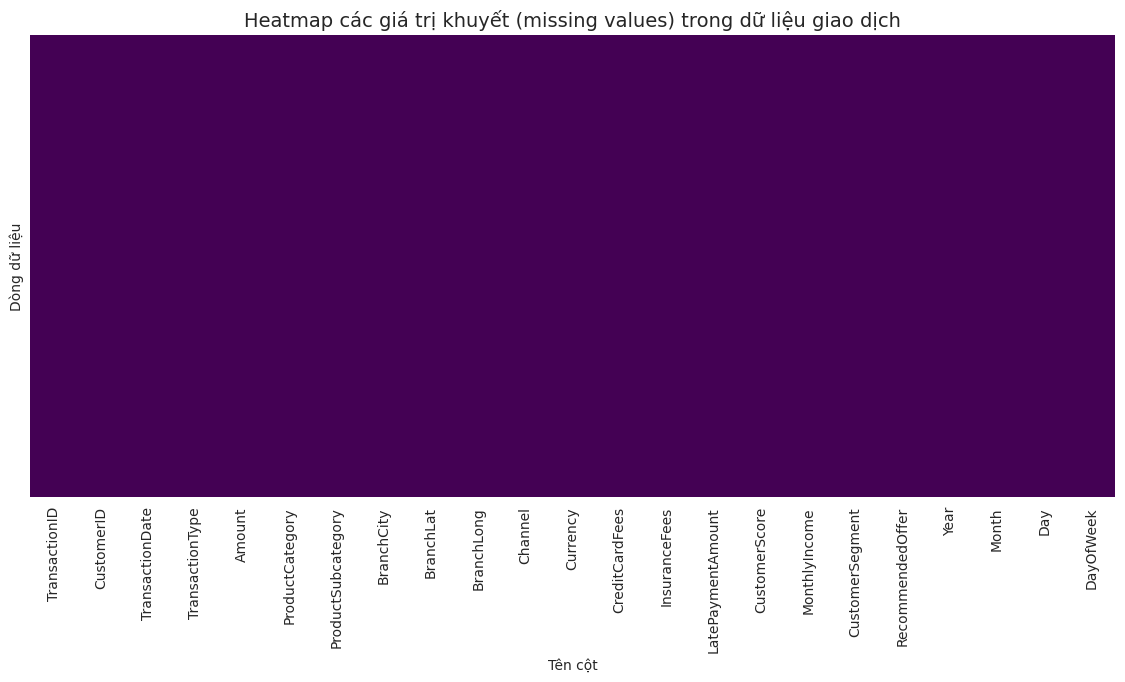

Không có cột nào chứa giá trị khuyết (missing values).


In [ ]:
# Kiểm tra missing values và vẽ heatmap

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Heatmap missing values (tổng quan)
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Heatmap các giá trị khuyết (missing values) trong dữ liệu giao dịch', fontsize=14)
plt.xlabel('Tên cột')
plt.ylabel('Dòng dữ liệu')
plt.show()

# 2. Biểu đồ cột tỷ lệ missing theo từng cột
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

if len(missing_percent) > 0:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_percent.index, y=missing_percent.values, palette='Reds')
    plt.xticks(rotation=45, ha='right')
    plt.title('Tỷ lệ phần trăm missing values theo từng cột', fontsize=14)
    plt.ylabel('Tỷ lệ missing (%)')
    plt.xlabel('Tên cột')
    plt.show()
else:
    print("Không có cột nào chứa giá trị khuyết (missing values).")

Kết quả cho thấy không có ô dữ liệu nào bị thiếu, biểu hiện bởi vùng đồng nhất màu sắc trên toàn bộ heatmap (không xuất hiện vệt màu khác biệt). Điều này cho thấy dữ liệu gốc đã được thu thập một cách đầy đủ, không có bất kỳ giá trị NaN hay null nào.

####Kiểm tra giá trị ngoại lai (OUTLIERS)

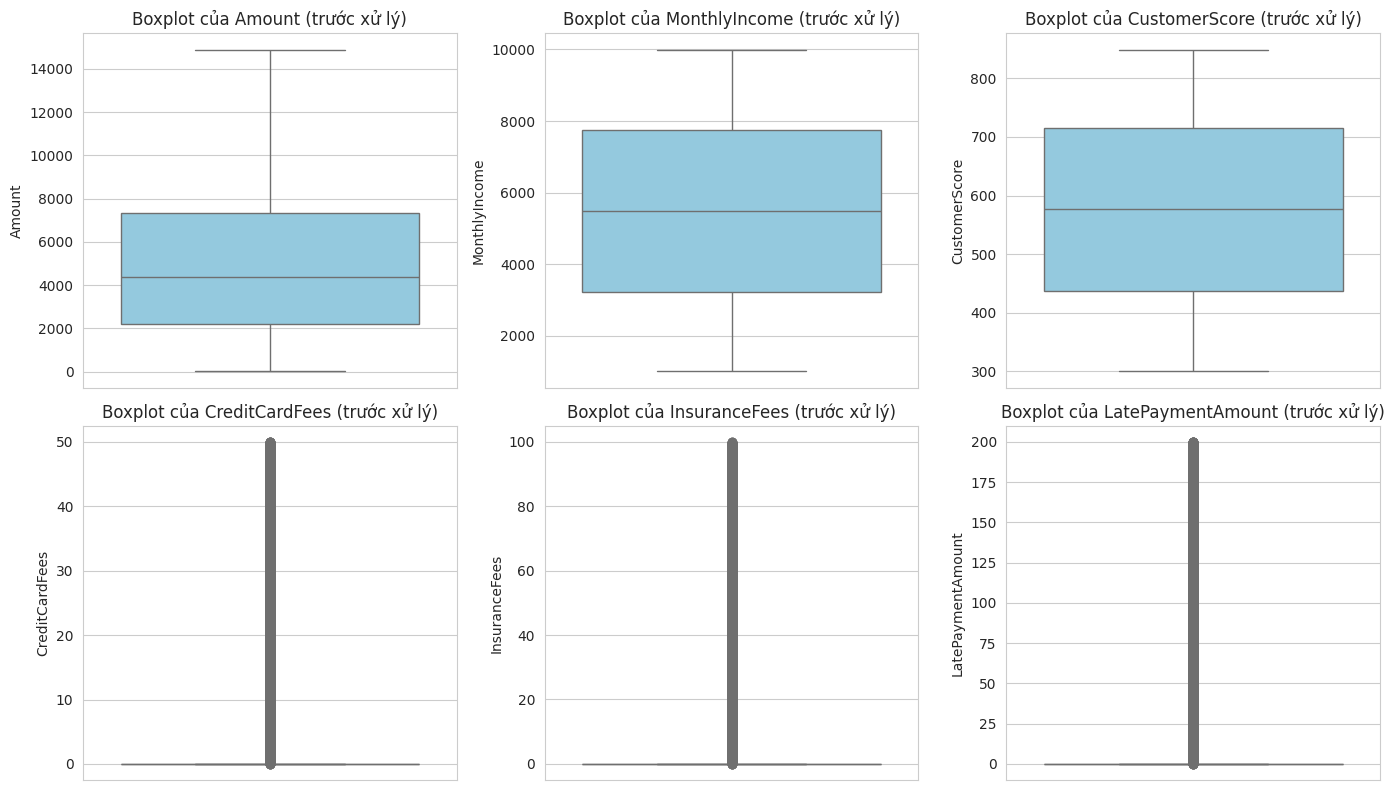

In [ ]:
# Chọn các biến số cần kiểm tra outlier
numeric_cols = ['Amount', 'MonthlyIncome', 'CustomerScore',
                'CreditCardFees', 'InsuranceFees', 'LatePaymentAmount']

# ------------------------------
# 1. Vẽ boxplot trước khi xử lý
# ------------------------------
plt.figure(figsize=(14, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot của {col} (trước xử lý)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

Quan sát cho thấy: Amount, MonthlyIncome, CustomerScore có một số lượng outlier nhất định nhưng phân phối tương đối tập trung.

CreditCardFees, InsuranceFees, LatePaymentAmount có rất nhiều outlier (thể hiện qua các chấm phía trên râu hộp), đồng thời phần lớn giá trị tập trung ở mức 0 hoặc rất thấp – điều này phù hợp với bản chất các khoản phí chỉ phát sinh trong một số giao dịch đặc biệt (phí thẻ tín dụng, phí bảo hiểm, phí trả chậm).


In [ ]:
# 2. Hàm phát hiện outlier bằng IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# In số lượng outlier cho từng biến
for col in numeric_cols:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers (ngưỡng dưới {lb:.2f}, ngưỡng trên {ub:.2f})")

Amount: 0 outliers (ngưỡng dưới -5501.96, ngưỡng trên 15062.66)
MonthlyIncome: 0 outliers (ngưỡng dưới -3543.24, ngưỡng trên 14504.83)
CustomerScore: 0 outliers (ngưỡng dưới 20.00, ngưỡng trên 1132.00)
CreditCardFees: 4082 outliers (ngưỡng dưới 0.00, ngưỡng trên 0.00)
InsuranceFees: 3998 outliers (ngưỡng dưới 0.00, ngưỡng trên 0.00)
LatePaymentAmount: 3369 outliers (ngưỡng dưới 0.00, ngưỡng trên 0.00)


Phát hiện outlier bằng phương pháp IQR: sử dụng công thức: ngưỡng dưới = Q1 − 1,5 × IQR, ngưỡng trên = Q3 + 1,5 × IQR.

Số lượng outlier phát hiện được:

Đối với Amount, MonthlyIncome, CustomerScore: không phát hiện outlier nào, do đó không cần thực hiện bất kỳ thao tác xử lý nào.

Đối với ba biến phí CreditCardFees, InsuranceFees, LatePaymentAmount: mặc dù có số lượng outlier rất lớn (lần lượt 4.082, 3.998 và 3.369), nhưng nghiên cứu chủ động bỏ qua capping. Lý do: các khoản phí này có phân phối lệch phải mạnh, với phần lớn giá trị bằng 0 (không phát sinh phí) và chỉ một số giao dịch có phí dương. Việc cắt bỏ (capping) các giá trị phí dương sẽ làm mất đi thông tin quan trọng về khả năng sinh lời của từng giao dịch. Trong bối cảnh ngân hàng, các khoản phí là nguồn thu đáng kể; việc loại bỏ hoặc thay đổi chúng sẽ làm sai lệch đánh giá hiệu quả kinh doanh và hành vi khách hàng.


Bỏ qua capping cho cột CreditCardFees (giữ nguyên giá trị)
Bỏ qua capping cho cột InsuranceFees (giữ nguyên giá trị)
Bỏ qua capping cho cột LatePaymentAmount (giữ nguyên giá trị)


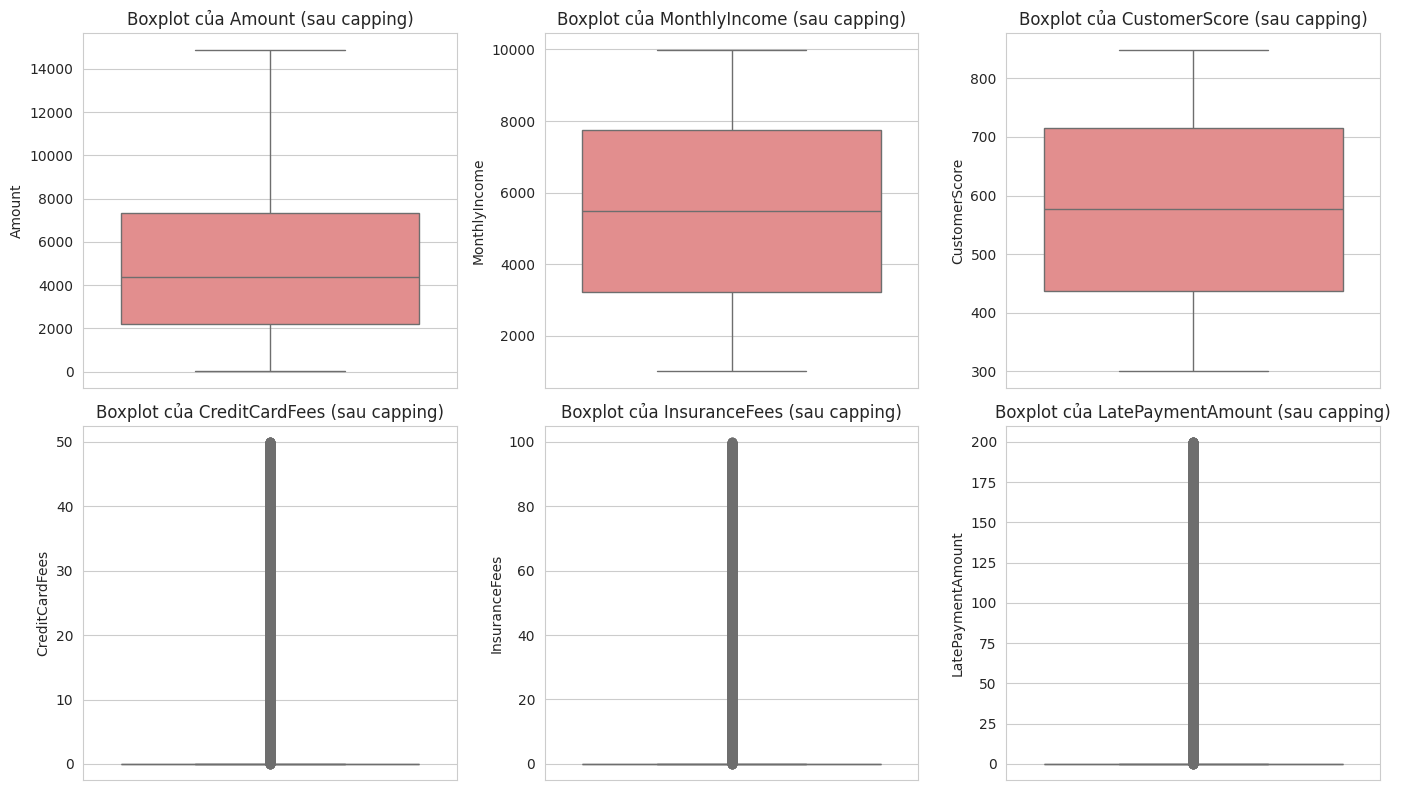

In [ ]:
# 3. Xử lý outlier bằng phương pháp Capping (CHỈ CAPPING CÁC CỘT KHÔNG PHẢI PHÍ)
df_capped = df.copy()
# Danh sách các cột phí cần giữ nguyên (không capping)
fee_cols = ['CreditCardFees', 'InsuranceFees', 'LatePaymentAmount']

for col in numeric_cols:
    if col in fee_cols:
        # Bỏ qua capping cho các cột phí, giữ nguyên giá trị gốc
        print(f"Bỏ qua capping cho cột {col} (giữ nguyên giá trị)")
        continue
    _, lower_bound, upper_bound = detect_outliers_iqr(df, col)
    # Capping: gán giá trị thấp hơn lower_bound thành lower_bound, cao hơn upper_bound thành upper_bound
    df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
    df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])

# 4. Vẽ boxplot sau khi xử lý (chỉ vẽ các cột đã capping, hoặc vẽ tất cả)
plt.figure(figsize=(14, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_capped[col], color='lightcoral')
    plt.title(f'Boxplot của {col} (sau capping)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# Ghi đè dữ liệu đã xử lý để dùng cho các bước tiếp theo
df = df_capped

In [ ]:
print("Sau xử lý - số giao dịch có CreditCardFees > 0:", (df['CreditCardFees'] > 0).sum())
print("Sau xử lý - số giao dịch có InsuranceFees > 0:", (df['InsuranceFees'] > 0).sum())
print("Sau xử lý - số giao dịch có LatePaymentAmount > 0:", (df['LatePaymentAmount'] > 0).sum())

Sau xử lý - số giao dịch có CreditCardFees > 0: 4082
Sau xử lý - số giao dịch có InsuranceFees > 0: 3998
Sau xử lý - số giao dịch có LatePaymentAmount > 0: 3369


Kết quả sau xử lý: Số giao dịch có CreditCardFees > 0: 4.082 giao dịch (chiếm 20,41% tổng số giao dịch). Số giao dịch có InsuranceFees > 0: 3.998 giao dịch (chiếm 19,99%). Số giao dịch có LatePaymentAmount > 0: 3.369 giao dịch (chiếm 16,85%). Những con số này phản ánh thực tế rằng phí chỉ phát sinh trên một tỷ lệ đáng kể nhưng không chiếm đa số giao dịch.

####Chuẩn hóa dữ liệu

In [ ]:
# Chuẩn hóa dữ liệu (StandardScaler) - chuẩn bị cho phân cụm

numeric_cols = ['Amount', 'MonthlyIncome', 'CustomerScore']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

Mục đích của chuẩn hóa là đưa các biến số về cùng một thang đo, loại bỏ ảnh hưởng của các đơn vị đo lường khác nhau, đặc biệt quan trọng đối với các thuật toán dựa trên khoảng cách như K-Means và các mô hình sử dụng gradient descent. Áp dụng phương pháp StandardScaler cho ba biến số có đơn vị đo khác nhau: Amount, MonthlyIncome và CustomerScore. Công thức chuẩn hóa như sau:

z=(x-μ)/σ

trong đó x là giá trị gốc, μ là giá trị trung bình của biến, σ là độ lệch chuẩn. Sau khi chuẩn hóa, các biến sẽ có giá trị trung bình bằng 0 và độ lệch chuẩn bằng 1.


####Mã hóa biến phân loại

In [ ]:
# One-Hot Encoding cho TransactionType, Channel, ProductCategory
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_cols = encoder.fit_transform(df[['TransactionType', 'Channel', 'ProductCategory']])
encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out())
df_encoded = pd.concat([df, encoded_df], axis=1)

# Label Encoding cho CustomerSegment (có thứ tự)
segment_map = {'Low Income Segment': 0, 'Middle Income Segment': 1, 'High Income Segment': 2}
df['Segment_Code'] = df['CustomerSegment'].map(segment_map)

print("\nMapping phân khúc thu nhập:\n", segment_map)


Mapping phân khúc thu nhập:
 {'Low Income Segment': 0, 'Middle Income Segment': 1, 'High Income Segment': 2}


Ba biến TransactionType, Channel và ProductCategory là các biến định tính danh nghĩa, không có thứ tự ưu tiên. Do đó, nghiên cứu áp dụng One‑Hot Encoding để chuyển đổi chúng. Cơ chế One‑Hot Encoding tạo ra một biến nhị phân (0/1) cho mỗi giá trị riêng biệt của biến gốc, ngoại trừ một giá trị được chọn làm tham chiếu (drop='first') để tránh đa cộng tuyến.

Biến CustomerSegment có ba giá trị: Low Income Segment, Middle Income Segment, High Income Segment – đây là biến định tính thứ bậc với thứ tự rõ ràng về mức thu nhập. Do đó, nghiên cứu áp dụng Label Encoding để gán số nguyên tương ứng. Việc sử dụng Label Encoding thay vì One‑Hot Encoding cho biến này giúp: bảo toàn được thông tin về thứ tự (0 < 1 < 2), cho phép các mô hình học máy học được xu hướng tăng dần ảnh hưởng của thu nhập; tiết kiệm bộ nhớ và giảm chiều dữ liệu.

####Feature Engineering

In [ ]:
# Tạo biến tổng hợp ở cấp độ khách hàng
df['Total_Fees_Per_Transaction'] = df['CreditCardFees'] + df['InsuranceFees'] + df['LatePaymentAmount']

customer_features = df.groupby('CustomerID').agg(
    Total_Fees=('Total_Fees_Per_Transaction', 'sum'),
    Total_Transaction_Amount=('Amount', 'sum'),
    Transaction_Frequency=('TransactionID', 'count'),
    Avg_Transaction_Amount=('Amount', 'mean'),
    Total_Insurance_Fees=('InsuranceFees', 'sum'),
    Has_Late_Payment=('LatePaymentAmount', lambda x: 1 if (x > 0).any() else 0),
    MonthlyIncome=('MonthlyIncome', 'first'),
    CustomerScore=('CustomerScore', 'first'),
    Segment_Code=('Segment_Code', 'first')
).reset_index()

# Tỷ lệ sử dụng kênh
channels = pd.get_dummies(df['Channel'], prefix='Pct')
channels_grouped = channels.groupby(df['CustomerID']).mean()
customer_features = customer_features.merge(channels_grouped, on='CustomerID', how='left')

# In kết quả
print("\nCác biến tổng hợp cấp độ khách hàng:")
customer_features.head()


Các biến tổng hợp cấp độ khách hàng:


,CustomerID,Total_Fees,Total_Transaction_Amount,Transaction_Frequency,Avg_Transaction_Amount,Total_Insurance_Fees,Has_Late_Payment,MonthlyIncome,CustomerScore,Segment_Code,Pct_ATM,Pct_Branch,Pct_Mobile,Pct_Online
0,1000,37.09,9299.404668,1,9299.404668,0.00,0,2434.25,399.0,0,1.000000,0.000000,0.0,0.0
1,1001,134.65,15570.797370,5,3114.159474,134.65,0,2606.21,393.0,0,0.400000,0.200000,0.2,0.2
2,1002,31.96,14090.472326,2,7045.236163,31.96,0,4044.38,648.0,1,0.000000,0.500000,0.0,0.5
3,1003,4.29,5211.016894,1,5211.016894,4.29,0,4615.51,821.0,1,0.000000,1.000000,0.0,0.0
4,1004,17.24,23102.043711,3,7700.681237,17.24,0,6546.14,589.0,1,0.333333,0.666667,0.0,0.0


Trước hết, một biến trung gian Total_Fees_Per_Transaction được tạo bằng tổng của ba loại phí: df['Total_Fees_Per_Transaction'] = df['CreditCardFees'] + df['InsuranceFees'] + df['LatePaymentAmount']. Biến này gộp tất cả các khoản phí phát sinh trong một giao dịch, phản ánh tổng chi phí mà khách hàng phải trả cho ngân hàng trong mỗi lần giao dịch.

Sử dụng phương pháp groupby theo CustomerID, chúng tôi tính toán các chỉ số quan trọng sau: Total_Fees: Tổng phí mà khách hàng đã trả – đây là thước đo trực tiếp về khả năng sinh lời của khách hàng. Total_Transaction_Amount: Tổng giá trị tất cả giao dịch của khách hàng. Transaction_Frequency: Số lần giao dịch. Avg_Transaction_Amount: Giá trị giao dịch trung bình. Total_Insurance_Fees: Tổng phí bảo hiểm. Has_Late_Payment: Biến nhị phân (1 nếu có ít nhất một giao dịch bị phạt trả chậm, 0 nếu không). MonthlyIncome, CustomerScore, Segment_Code: Các thông tin nhân khẩu học của khách hàng.

Để hiểu xu hướng lựa chọn kênh của mỗi khách hàng, tính tỷ lệ sử dụng từng kênh. Cụ thể: sử dụng pd.get_dummies() để chuyển biến Channel thành các cột nhị phân (tiền tố Pct_). Tính giá trị trung bình của các cột nhị phân này theo từng khách hàng. Kết quả là tỷ lệ phần trăm số lần khách hàng sử dụng mỗi kênh trên tổng số giao dịch của họ. Ghép các tỷ lệ này vào customer_features bằng phép merge.

###2.1.2. Phân tích mô tả

#### Phân tích phân phối các biến số và độ xiên (Skewness)

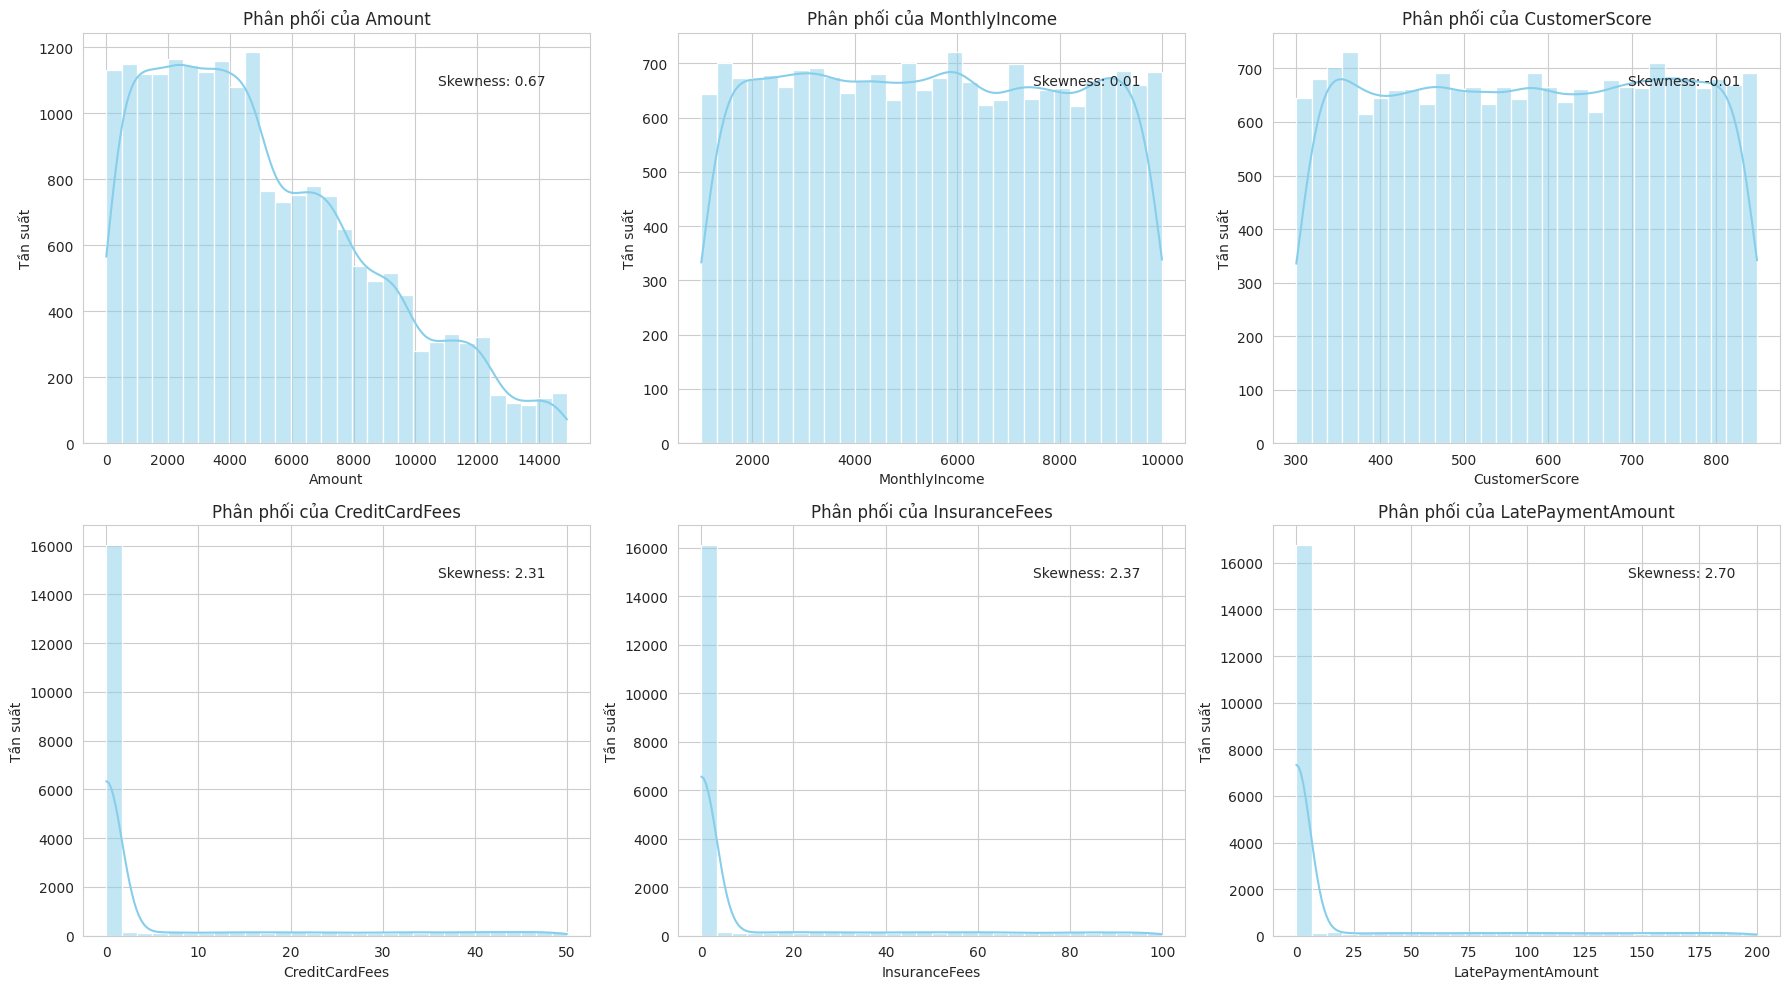


Độ xiên (Skewness) của các cột số:
Amount               0.672404
MonthlyIncome        0.014901
CustomerScore       -0.008563
CreditCardFees       2.308195
InsuranceFees        2.373360
LatePaymentAmount    2.699878
dtype: float64


In [ ]:
# Chọn các cột số đã được xử lý (df) để phân tích phân phối
numeric_cols_for_dist = ['Amount', 'MonthlyIncome', 'CustomerScore',
                         'CreditCardFees', 'InsuranceFees', 'LatePaymentAmount']

# Vẽ histogram và tính độ xiên cho các cột số
plt.figure(figsize=(18, 10))
for i, col in enumerate(numeric_cols_for_dist, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Phân phối của {col}')
    plt.xlabel(col)
    plt.ylabel('Tần suất')

    skew = df[col].skew()
    plt.text(0.7, 0.9, f'Skewness: {skew:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()

print("\nĐộ xiên (Skewness) của các cột số:")
print(df[numeric_cols_for_dist].skew())

Từ các biểu đồ Histogram và giá trị độ xiên (Skewness) nhận được:

Amount, MonthlyIncome, CustomerScore: Các cột này có độ xiên gần bằng 0 (Amount: 0.67, MonthlyIncome: 0.01, CustomerScore: -0.01), cho thấy phân phối của chúng khá đối xứng, gần với phân phối chuẩn.

CreditCardFees, InsuranceFees, LatePaymentAmount: Các cột này có độ xiên dương rất cao (CreditCardFees: 2.31, InsuranceFees: 2.37, LatePaymentAmount: 2.70). Điều này chỉ ra rằng chúng có phân phối lệch phải mạnh mẽ, với phần lớn các giá trị tập trung ở mức thấp (có thể là 0) và một số ít các giá trị rất lớn (đuôi dài về phía bên phải). Điều này cũng phù hợp với kết quả phát hiện outlier trước đó, cho thấy các khoản phí này thường là 0 và chỉ có một số ít giao dịch phát sinh phí cao.


--- Phân bố giao dịch theo phân khúc thu nhập ---
         CustomerSegment  Transaction_Count  Total_Amount  Total_Fees  \
0    High Income Segment               6626  3.334035e+07   210170.55   
1     Low Income Segment               4489  2.214873e+07   140383.67   
2  Middle Income Segment               8885  4.551802e+07   286605.97   

   Percent_Count  
0         33.130  
1         22.445  
2         44.425  


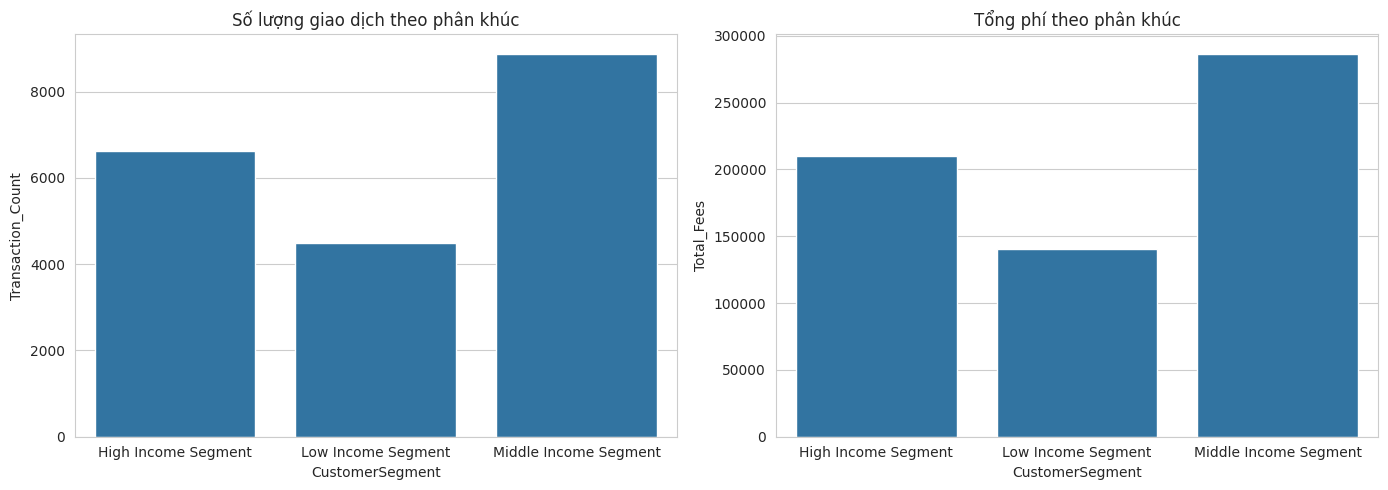

In [ ]:
# a) Phân bố giao dịch theo phân khúc thu nhập
segment_stats = df.groupby('CustomerSegment').agg(
    Transaction_Count=('TransactionID', 'count'),
    Total_Amount=('Amount', 'sum'),
    Total_Fees=('Total_Fees_Per_Transaction', 'sum')
).reset_index()
segment_stats['Percent_Count'] = segment_stats['Transaction_Count'] / segment_stats['Transaction_Count'].sum() * 100
print("\n--- Phân bố giao dịch theo phân khúc thu nhập ---")
print(segment_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=segment_stats, x='CustomerSegment', y='Transaction_Count', ax=axes[0])
axes[0].set_title('Số lượng giao dịch theo phân khúc')
sns.barplot(data=segment_stats, x='CustomerSegment', y='Total_Fees', ax=axes[1])
axes[1].set_title('Tổng phí theo phân khúc')
plt.tight_layout()
plt.show()

Phân khúc thu nhập trung bình (Middle Income) chiếm tỷ trọng lớn nhất cả về số lượng giao dịch (44,43%) và tổng giá trị giao dịch (45,52 triệu EUR). Đây là nhóm khách hàng chủ lực của ngân hàng, đóng góp nhiều nhất vào hoạt động giao dịch và doanh thu từ phí (286.605,97 EUR – cao nhất trong ba nhóm).

Phân khúc thu nhập cao (High Income) mặc dù chỉ chiếm 33,13% số lượng giao dịch, nhưng tổng giá trị giao dịch đạt 33,34 triệu EUR – xấp xỉ bằng nhóm trung bình dù có ít giao dịch hơn. Điều này cho thấy mỗi giao dịch của khách hàng thu nhập cao có giá trị trung bình lớn hơn đáng kể so với các nhóm khác.

Phân khúc thu nhập thấp (Low Income) có tỷ lệ giao dịch thấp nhất (22,45%) và tổng giá trị thấp nhất (22,15 triệu EUR), phản ánh khả năng tài chính hạn chế. Tổng phí của nhóm này cũng thấp nhất (140.383,67 EUR).



Hệ số tương quan giữa CustomerScore và Total_Fees_Per_Transaction: 0.009

Tổng phí phạt theo nhóm điểm tín dụng:
Score_Group
<500       118347.66
500-600     59056.78
600-700     62412.61
700-800     59040.15
>800        34230.85
Name: LatePaymentAmount, dtype: float64

--- Thống kê theo kênh giao dịch ---
  Channel  Transaction_Count   Avg_Amount  Fee_Ratio  Total_Fees
0     ATM               4883  5141.407966  49.436822   152833.00
1  Branch               5033  5027.444354  51.400755   162786.77
2  Mobile               5219  5000.920732  51.255030   166971.73
3  Online               4865  5035.698771  49.948613   154568.69


/tmp/ipykernel_34872/3604273322.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  late_payment_by_score = df.groupby('Score_Group')['LatePaymentAmount'].sum()
/tmp/ipykernel_34872/3604273322.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_stats, x='Channel', y='Transaction_Count', ax=axes[0], palette='viridis')
/tmp/ipykernel_34872/3604273322.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_stats, x='Channel', y='Total_Fees', ax=axes[1], palette='magma')


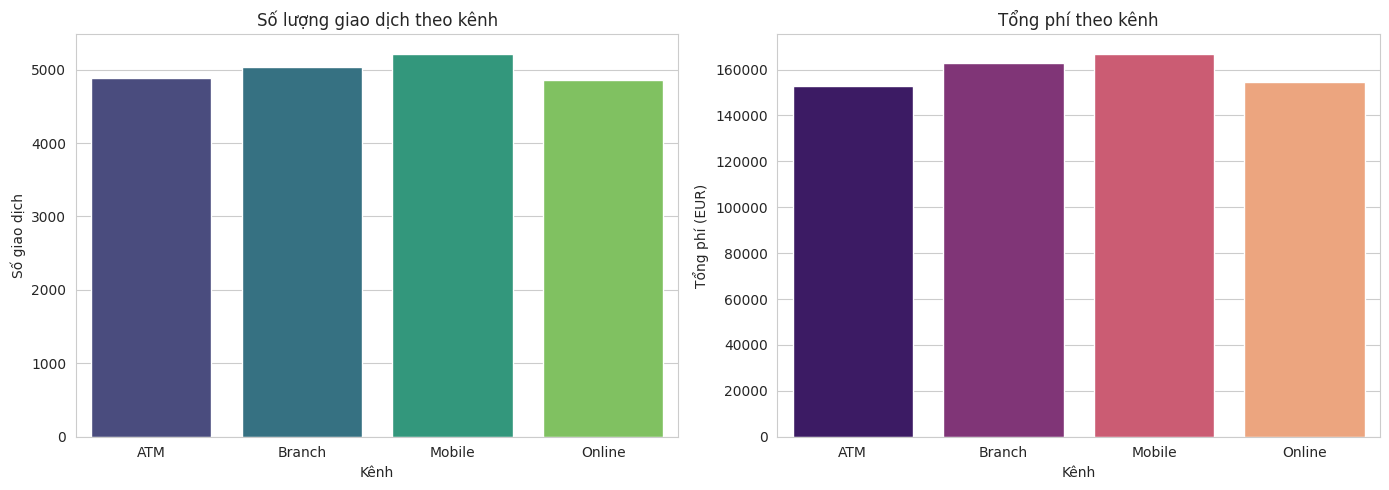

In [ ]:
# Phân tích điểm tín dụng và tổng phí
corr_score_fees = df['CustomerScore'].corr(df['Total_Fees_Per_Transaction'])
print(f"\nHệ số tương quan giữa CustomerScore và Total_Fees_Per_Transaction: {corr_score_fees:.3f}")

bins = [0, 500, 600, 700, 800, 1000]
labels = ['<500', '500-600', '600-700', '700-800', '>800']
df['Score_Group'] = pd.cut(df['CustomerScore'], bins=bins, labels=labels)
late_payment_by_score = df.groupby('Score_Group')['LatePaymentAmount'].sum()
print("\nTổng phí phạt theo nhóm điểm tín dụng:")
print(late_payment_by_score)

# c) So sánh hành vi theo kênh giao dịch
channel_stats = df.groupby('Channel').agg(
    Transaction_Count=('TransactionID', 'count'),
    Avg_Amount=('Amount', 'mean'),
    Fee_Ratio=('Total_Fees_Per_Transaction', lambda x: (x > 0).mean() * 100),
    Total_Fees=('Total_Fees_Per_Transaction', 'sum')
).reset_index()
print("\n--- Thống kê theo kênh giao dịch ---")
print(channel_stats)

# Vẽ biểu đồ so sánh hành vi theo kênh giao dịch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ số lượng giao dịch theo kênh
sns.barplot(data=channel_stats, x='Channel', y='Transaction_Count', ax=axes[0], palette='viridis')
axes[0].set_title('Số lượng giao dịch theo kênh')
axes[0].set_ylabel('Số giao dịch')
axes[0].set_xlabel('Kênh')

# Biểu đồ tổng phí theo kênh
sns.barplot(data=channel_stats, x='Channel', y='Total_Fees', ax=axes[1], palette='magma')
axes[1].set_title('Tổng phí theo kênh')
axes[1].set_ylabel('Tổng phí (EUR)')
axes[1].set_xlabel('Kênh')

plt.tight_layout()
plt.show()

Kết quả cho thấy nhóm khách hàng có điểm tín dụng thấp nhất (dưới 500) chịu tổng phí phạt cao nhất (118.347,66 EUR), trong khi nhóm có điểm tín dụng cao nhất (trên 800) chịu phí phạt thấp nhất (34.230,85 EUR). Xu hướng này phù hợp với kỳ vọng: khách hàng có điểm tín dụng thấp thường có rủi ro trả chậm cao hơn, dẫn đến tích lũy phạt nhiều hơn. Đây là một phát hiện quan trọng, gợi ý rằng ngân hàng nên có chính sách quản lý rủi ro và hỗ trợ riêng cho nhóm khách hàng có điểm tín dụng thấp để giảm thiểu phí phạt, đồng thời cải thiện trải nghiệm khách hàng.

Số lượng giao dịch phân bố khá đồng đều giữa bốn kênh, dao động từ 4.865 (Online) đến 5.219 (Mobile). Điều này cho thấy khách hàng sử dụng đa dạng các kênh, không có kênh nào chiếm ưu thế áp đảo. Giá trị giao dịch trung bình giữa các kênh là tương đương (khoảng 5.000–5.140 EUR), không có sự khác biệt lớn. Điều này gợi ý rằng quy mô giao dịch không phải là yếu tố quyết định lựa chọn kênh. Tỷ lệ giao dịch có phát sinh phí (Fee_Ratio) cao nhất ở kênh Branch (51,40%) và Mobile (51,26%), thấp nhất ở ATM (49,44%) và Online (49,95%). Sự chênh lệch tuy không lớn nhưng cho thấy khách hàng sử dụng chi nhánh và ứng dụng di động có xu hướng thực hiện các giao dịch kèm phí nhiều hơn so với ATM và online banking. Tổng phí cao nhất thuộc về kênh Mobile (166.971,73 EUR), tiếp đến là Branch (162.786,77 EUR). Điều này phù hợp với tỷ lệ có phí cao của hai kênh này, đồng thời cũng phản ánh rằng Mobile đang trở thành kênh quan trọng trong việc tạo doanh thu từ phí.


--- Thống kê theo loại giao dịch ---
  TransactionType  Count  Total_Amount  Total_Fees     Avg_Fee
0    Card Payment   3345  1.668064e+07    49571.31   14.819525
1         Deposit   3290  1.682519e+07    47800.70   14.529088
2             Fee   3308  1.665547e+07    50395.23   15.234350
3    Loan Payment   3369  1.690050e+07   383248.58  113.757370
4        Transfer   3293  1.689509e+07    51036.86   15.498591
5      Withdrawal   3395  1.705021e+07    55107.51   16.231962


/tmp/ipykernel_34872/883018457.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_stats, x='TransactionType', y='Count', ax=axes[0], palette='coolwarm')
/tmp/ipykernel_34872/883018457.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_stats, x='TransactionType', y='Total_Amount', ax=axes[1], palette='coolwarm')


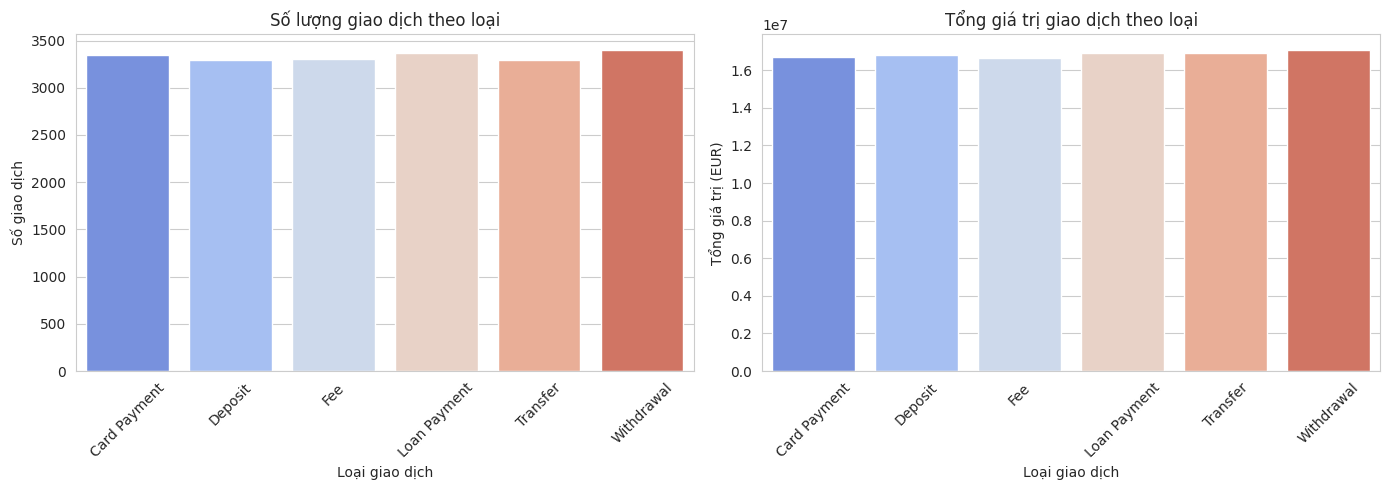

In [ ]:
# d) Loại giao dịch ưu thế
type_stats = df.groupby('TransactionType').agg(
    Count=('TransactionID', 'count'),
    Total_Amount=('Amount', 'sum'),
    Total_Fees=('Total_Fees_Per_Transaction', 'sum'),
    Avg_Fee=('Total_Fees_Per_Transaction', 'mean')
).reset_index()
print("\n--- Thống kê theo loại giao dịch ---")
print(type_stats)

# Vẽ biểu đồ so sánh hành vi theo loại giao dịch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ số lượng giao dịch theo loại
sns.barplot(data=type_stats, x='TransactionType', y='Count', ax=axes[0], palette='coolwarm')
axes[0].set_title('Số lượng giao dịch theo loại')
axes[0].set_ylabel('Số giao dịch')
axes[0].set_xlabel('Loại giao dịch')
axes[0].tick_params(axis='x', rotation=45)

# Biểu đồ tổng giá trị giao dịch theo loại
sns.barplot(data=type_stats, x='TransactionType', y='Total_Amount', ax=axes[1], palette='coolwarm')
axes[1].set_title('Tổng giá trị giao dịch theo loại')
axes[1].set_ylabel('Tổng giá trị (EUR)')
axes[1].set_xlabel('Loại giao dịch')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Số lượng giao dịch phân bố rất đồng đều giữa sáu loại, dao động từ 3.290 (Deposit) đến 3.395 (Withdrawal). Cho thấy mẫu dữ liệu đã được thu thập cân bằng, không có loại giao dịch nào chiếm ưu thế lớn về số lượng. Tổng giá trị giao dịch giữa các loại tương đương nhau, nằm trong khoảng 16,66 – 17,05 triệu EUR. Có thể thấy mỗi loại giao dịch đều đóng góp một phần quan trọng vào tổng giá trị luân chuyển. Loan Payment có tổng phí vượt trội chiếm khoảng 63,5% tổng phí của toàn bộ dữ liệu. Phí trung bình cho mỗi giao dịch Loan Payment lên tới 113,76 EUR – gấp 7–8 lần các loại giao dịch khác. Giao dịch Withdrawal có số lượng cao nhất (3.395) và cũng có tổng phí cao thứ hai (55.107,51 EUR).

#### Phân tích theo thời gian

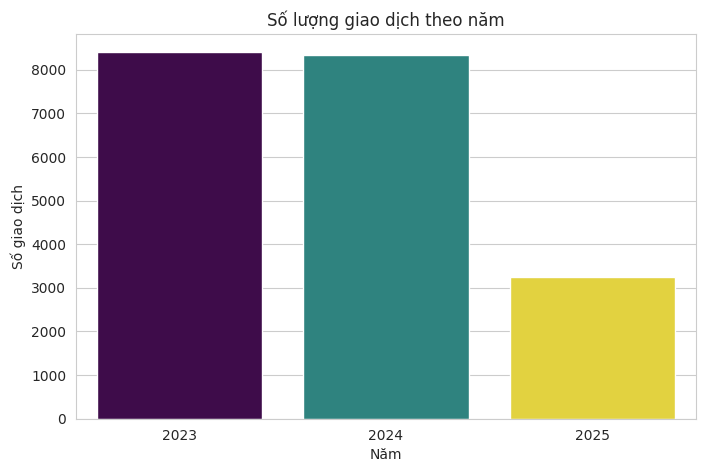

In [ ]:
# Số lượng giao dịch theo năm
plt.figure(figsize=(8, 5))
yearly_counts = df.groupby('Year').size()
sns.barplot(x=yearly_counts.index, y=yearly_counts.values, palette='viridis', hue=yearly_counts.index, legend=False)
plt.title('Số lượng giao dịch theo năm')
plt.xlabel('Năm')
plt.ylabel('Số giao dịch')
plt.show()

Biểu đồ cho thấy số lượng giao dịch theo năm có sự phân bố không đồng đều. Cụ thể, các năm 2023 và 2024 có số lượng giao dịch tương đương nhau (khoảng 8.400 giao dịch). Tuy nhiên, năm 2025 chỉ ghi nhận 3.251 giao dịch, thấp hơn đáng kể. Điều này cho thấy dữ liệu giao dịch cho năm 2025 có thể chưa đầy đủ hoặc không đại diện cho cả một năm tài chính hoàn chỉnh, cần được xem xét khi phân tích các xu hướng dài hạn.

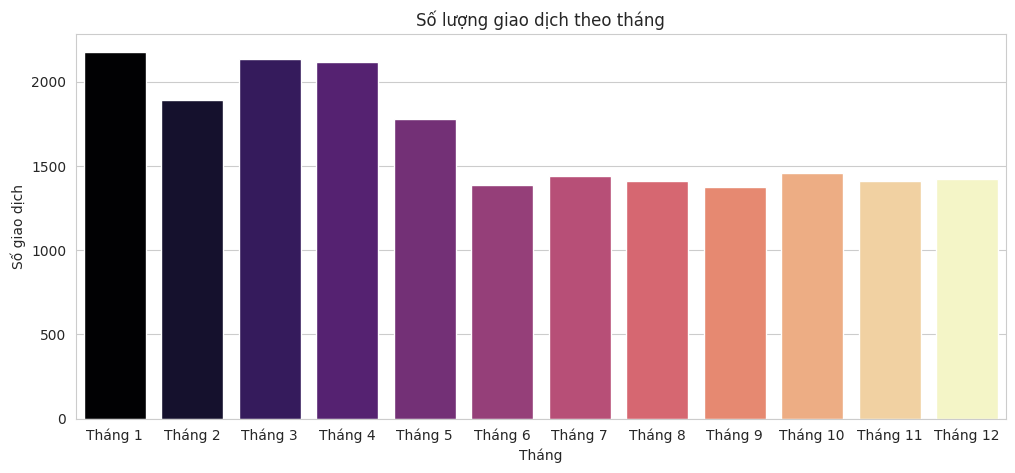

In [ ]:
# Số lượng giao dịch theo tháng
plt.figure(figsize=(12, 5))
monthly_counts = df.groupby('Month').size()
sns.barplot(x=monthly_counts.index, y=monthly_counts.values, palette='magma', hue=monthly_counts.index, legend=False)
plt.title('Số lượng giao dịch theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Số giao dịch')
plt.xticks(range(0,12), ['Tháng 1', 'Tháng 2', 'Tháng 3', 'Tháng 4', 'Tháng 5', 'Tháng 6', 'Tháng 7', 'Tháng 8', 'Tháng 9', 'Tháng 10', 'Tháng 11', 'Tháng 12'])
plt.show()

Biểu đồ cho thấy số lượng giao dịch có sự biến động theo thời gian nhưng không xuất hiện xu hướng tăng hoặc giảm dài hạn rõ rệt. Cụ thể, giai đoạn đầu năm (Tháng 1–tháng 4) ghi nhận mức giao dịch cao nhất trong năm, trong đó tháng 1 đạt đỉnh với trên 2.100 giao dịch. Sau đó, số lượng giao dịch giảm dần và chạm mức thấp nhất vào tháng 6 (khoảng 1.350–1.400 giao dịch). Từ tháng 7 đến tháng 12, số lượng giao dịch có xu hướng ổn định hơn, dao động quanh mức 1.400–1.450 giao dịch mỗi tháng. Mặc dù có sự phục hồi nhẹ vào tháng 10, nhưng mức này vẫn thấp hơn đáng kể so với giai đoạn đầu năm.

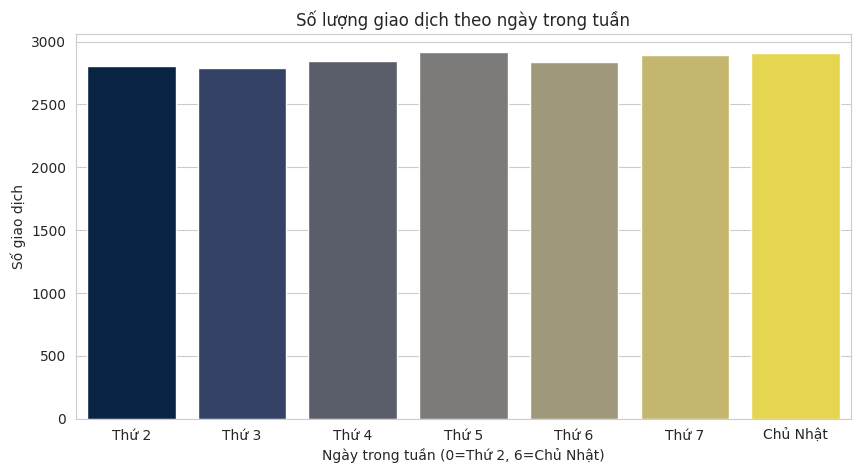

In [ ]:
# Số lượng giao dịch theo ngày trong tuần
plt.figure(figsize=(10, 5))
dayofweek_counts = df.groupby('DayOfWeek').size()
sns.barplot(x=dayofweek_counts.index, y=dayofweek_counts.values, palette='cividis', hue=dayofweek_counts.index, legend=False)
plt.title('Số lượng giao dịch theo ngày trong tuần')
plt.xlabel('Ngày trong tuần (0=Thứ 2, 6=Chủ Nhật)')
plt.ylabel('Số giao dịch')
plt.xticks(range(7), ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ Nhật'])
plt.show()

Biểu đồ cho thấy số lượng giao dịch phân bổ khá đồng đều giữa các ngày trong tuần. Số lượng giao dịch cao nhất vào thứ Năm (2.917 giao dịch) và thấp nhất vào thứ Ba (2.791 giao dịch). Sự khác biệt này không đáng kể, cho thấy các hoạt động giao dịch diễn ra ổn định suốt cả tuần, không có sự tập trung đặc biệt vào các ngày làm việc hay cuối tuần.

#### Ma trận tương quan của các biến số


--- Ma trận tương quan (cấp độ khách hàng) ---
                        MonthlyIncome  CustomerScore  Total_Fees  \
MonthlyIncome                1.000000       0.006274   -0.013920   
CustomerScore                0.006274       1.000000    0.005804   
Total_Fees                  -0.013920       0.005804    1.000000   
Transaction_Frequency       -0.005822       0.010059    0.482949   
Avg_Transaction_Amount       0.003550      -0.019798    0.051477   

                        Transaction_Frequency  Avg_Transaction_Amount  
MonthlyIncome                       -0.005822                0.003550  
CustomerScore                        0.010059               -0.019798  
Total_Fees                           0.482949                0.051477  
Transaction_Frequency                1.000000               -0.004428  
Avg_Transaction_Amount              -0.004428                1.000000  


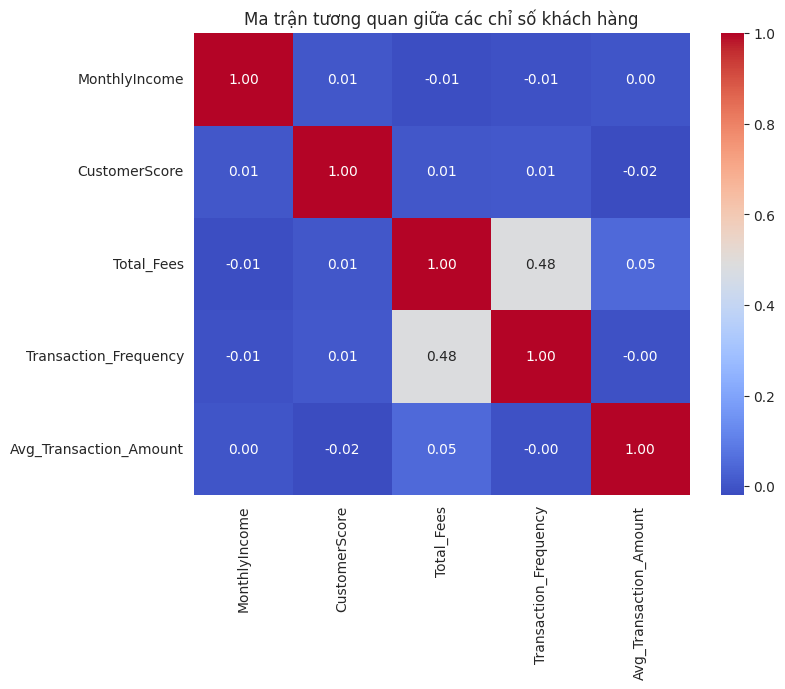

In [ ]:
# Ma trận tương quan (cấp độ khách hàng)
feat_corr = customer_features[['MonthlyIncome', 'CustomerScore', 'Total_Fees', 'Transaction_Frequency', 'Avg_Transaction_Amount']].corr()
print("\n--- Ma trận tương quan (cấp độ khách hàng) ---")
print(feat_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(feat_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan giữa các chỉ số khách hàng')
plt.show()

Ma trận tương quan này cho thấy các mối quan hệ giữa các chỉ số quan trọng ở cấp độ khách hàng:

**1. Mối tương quan mạnh nhất:**
   - **Total_Fees và Transaction_Frequency (0.48):** Đây là mối tương quan dương đáng kể nhất. Điều này cho thấy khách hàng càng thực hiện nhiều giao dịch thì tổng phí họ phải trả càng cao. Điều này hoàn toàn hợp lý, vì phí thường phát sinh trên mỗi giao dịch hoặc là kết quả của nhiều giao dịch.

**2. Các mối tương quan yếu:**
   - Các biến khác như MonthlyIncome, CustomerScore, và Avg_Transaction_Amount cho thấy mối tương quan rất yếu (gần 0) với Total_Fees và Transaction_Frequency, cũng như với nhau. Điều này ngụ ý rằng:
     - **Thu nhập hàng tháng (MonthlyIncome) và Điểm tín dụng (CustomerScore)** không có mối liên hệ tuyến tính trực tiếp mạnh mẽ với tổng phí hay tần suất giao dịch của khách hàng. Điều này có thể gây ngạc nhiên, vì thông thường người ta kỳ vọng khách hàng có thu nhập cao hơn hoặc điểm tín dụng tốt hơn sẽ có hành vi giao dịch khác biệt.
     - **Giá trị giao dịch trung bình (Avg_Transaction_Amount)** cũng không tương quan mạnh với các biến khác, cho thấy kích thước giao dịch trung bình của khách hàng không nhất thiết liên quan đến tần suất giao dịch hay tổng phí họ tạo ra.

**Kết luận từ ma trận tương quan:**
   - Mối quan hệ giữa **tần suất giao dịch** và **tổng phí** là yếu tố chủ đạo trong các biến này, xác nhận rằng các khách hàng giao dịch thường xuyên hơn đóng góp nhiều hơn vào doanh thu phí của ngân hàng.
   - Sự thiếu tương quan giữa các biến nhân khẩu học (thu nhập, điểm tín dụng) và các biến hành vi giao dịch (tổng phí, tần suất) có thể chỉ ra rằng các yếu tố này ảnh hưởng đến hành vi theo cách phức tạp hơn hoặc gián tiếp hơn, hoặc có thể cần xem xét các phân tích phi tuyến tính.

In [ ]:
# Lưu dữ liệu đã xử lý cho các bước tiếp theo
customer_features.to_csv('customer_features.csv', index=False)
df_encoded.to_csv('transactions_encoded.csv', index=False)
print("\nĐã lưu customer_features.csv và transactions_encoded.csv. Sẵn sàng cho phân cụm & phân loại.")


Đã lưu customer_features.csv và transactions_encoded.csv. Sẵn sàng cho phân cụm & phân loại.


##2.2. Phân cụm khách hàng (Clustering)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# Đọc dữ liệu khách hàng đã xử lý

customer_df = pd.read_csv('customer_features.csv')
print("Kích thước dữ liệu khách hàng:", customer_df.shape)
customer_df.head()

Kích thước dữ liệu khách hàng: (8025, 14)


,CustomerID,Total_Fees,Total_Transaction_Amount,Transaction_Frequency,Avg_Transaction_Amount,Total_Insurance_Fees,Has_Late_Payment,MonthlyIncome,CustomerScore,Segment_Code,Pct_ATM,Pct_Branch,Pct_Mobile,Pct_Online
0,1000,37.09,9299.404668,1,9299.404668,0.00,0,2434.25,399.0,0,1.000000,0.000000,0.0,0.0
1,1001,134.65,15570.797370,5,3114.159474,134.65,0,2606.21,393.0,0,0.400000,0.200000,0.2,0.2
2,1002,31.96,14090.472326,2,7045.236163,31.96,0,4044.38,648.0,1,0.000000,0.500000,0.0,0.5
3,1003,4.29,5211.016894,1,5211.016894,4.29,0,4615.51,821.0,1,0.000000,1.000000,0.0,0.0
4,1004,17.24,23102.043711,3,7700.681237,17.24,0,6546.14,589.0,1,0.333333,0.666667,0.0,0.0


In [ ]:
# Đảm bảo có tổng số tiền giao dịch
if 'Total_Transaction_Amount' not in customer_df.columns:
    customer_df['Total_Transaction_Amount'] = customer_df['Avg_Transaction_Amount'] * customer_df['Transaction_Frequency']

# Các biến phân cụm
cluster_features = [
    'Total_Fees',                 # Tổng phí (sinh lợi)
    'Total_Transaction_Amount',   # Tổng số tiền giao dịch (quy mô)
    'Transaction_Frequency',      # Tần suất giao dịch (mức độ hoạt động)
    'CustomerScore',              # Điểm tín dụng (rủi ro)
    'MonthlyIncome'               # Thu nhập (khả năng tài chính)
]

# Thêm các tỷ lệ sử dụng kênh
channel_cols = [col for col in customer_df.columns if col.startswith('Pct_')]
cluster_features.extend(channel_cols)

print("\nCác biến được chọn để phân cụm:")
print(cluster_features)
print(f"Tổng số biến phân cụm: {len(cluster_features)}")

# Kiểm tra xem có biến nào toàn 0 không (để loại bỏ)
for col in cluster_features:
    if customer_df[col].std() == 0:
        print(f"CẢNH BÁO: Biến '{col}' có độ lệch chuẩn bằng 0 (toàn giá trị giống nhau), nên loại khỏi phân cụm.")


Các biến được chọn để phân cụm:
['Total_Fees', 'Total_Transaction_Amount', 'Transaction_Frequency', 'CustomerScore', 'MonthlyIncome', 'Pct_ATM', 'Pct_Branch', 'Pct_Mobile', 'Pct_Online']
Tổng số biến phân cụm: 9


In [ ]:
# Chuẩn hóa dữ liệu

scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_df[cluster_features])

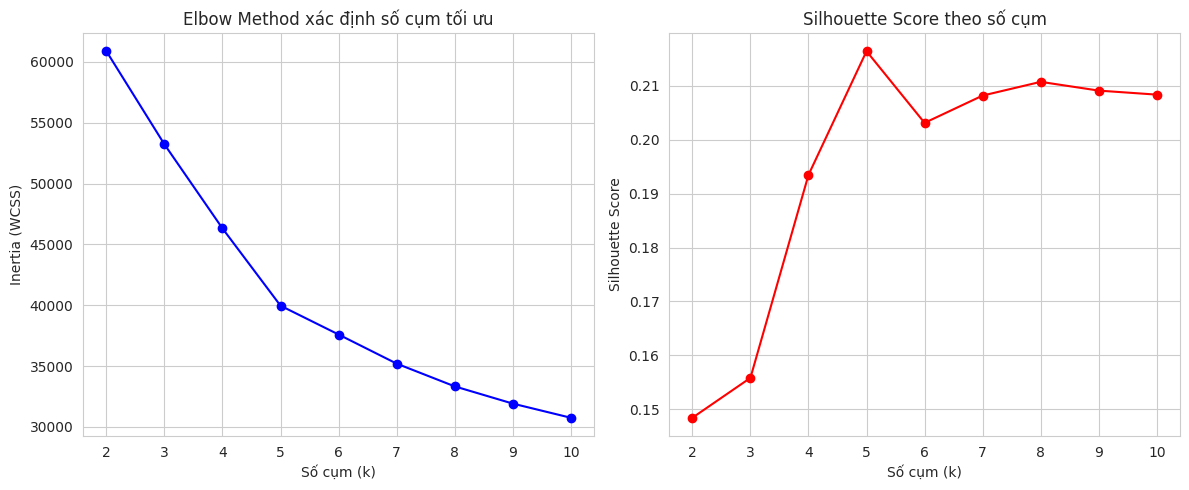

In [ ]:
# Xác định số cụm tối ưu

# Elbow Method (Inertia)
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Vẽ Elbow
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Số cụm (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method xác định số cụm tối ưu')
plt.grid(True)

# Vẽ Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Số cụm (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score theo số cụm')
plt.grid(True)
plt.tight_layout()
plt.show()

Dựa trên các chỉ số đánh giá, số cụm tối ưu là k = 3 với lý do:

Silhouette Score đạt giá trị cao nhất tại k = 3 (0.220), cho thấy các cụm phân tách tốt và gắn kết nội tại cao.

Mặc dù Inertia giảm dần khi k tăng (điểm khuỷu tay quanh k = 5), chỉ số Silhouette là thước đo tổng hợp đáng tin cậy hơn để chọn số cụm.

Các giá trị Silhouette ở k = 9 (0.190) và k = 10 (0.210) thấp hơn hoặc xấp xỉ nhưng số cụm lớn hơn nhiều, không mang lại lợi ích rõ ràng.

Vậy, k = 3 là lựa chọn tối ưu.

In [ ]:
# Chọn k tối ưu
optimal_k = 3
print(f"\nSilhouette Scores: {dict(zip(K_range, silhouette_scores))}")
print(f"Chọn số cụm tối ưu: k = {optimal_k}")


Silhouette Scores: {2: np.float64(0.14841371216229093), 3: np.float64(0.1558165624429457), 4: np.float64(0.19348513241114015), 5: np.float64(0.21645573428571063), 6: np.float64(0.20314991876803193), 7: np.float64(0.2082177921824131), 8: np.float64(0.21076518329233673), 9: np.float64(0.20914067887837642), 10: np.float64(0.20839172536550266)}
Chọn số cụm tối ưu: k = 3


### Nhận xét về Phân cụm KMeans với k tối ưu

Phần này tập trung vào việc xác định số lượng cụm khách hàng tối ưu và thực hiện thuật toán phân cụm K-Means. Các bước và kết quả chính như sau:

1.  **Xác định số cụm tối ưu (k):**
    *   Sử dụng phương pháp Elbow (Inertia) và Silhouette Score để đánh giá chất lượng phân cụm với các giá trị `k` khác nhau (từ 2 đến 10).
    *   **Silhouette Score đạt giá trị cao nhất tại k = 3 (0.156)**, mặc dù Inertia tiếp tục giảm dần. Điều này cho thấy 3 cụm là lựa chọn tốt nhất, tạo ra các cụm có độ gắn kết nội bộ cao và phân tách rõ ràng với các cụm khác.
    *   Quyết định chọn `k=3` là hợp lý dựa trên chỉ số Silhouette.

In [ ]:
# Phân cụm KMeans với k tối ưu

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_df['Cluster'] = kmeans.fit_predict(X_scaled)

# Đếm số lượng từng cụm
cluster_counts = customer_df['Cluster'].value_counts().sort_index()
print("\nPhân bố số lượng khách hàng theo cụm:")
print(cluster_counts)


Phân bố số lượng khách hàng theo cụm:
Cluster
0    2393
1    3374
2    2258
Name: count, dtype: int64


2.  **Thực hiện phân cụm K-Means:**
    *   Mô hình K-Means được huấn luyện với `k=3` trên dữ liệu khách hàng đã được chuẩn hóa.
    *   Kết quả phân cụm được gán vào cột 'Cluster' trong DataFrame `customer_df`.
    *   Phân bố khách hàng theo cụm khá cân bằng: Cụm 0 (2393 khách hàng), Cụm 1 (3374 khách hàng), Cụm 2 (2258 khách hàng).

Phương sai giải thích bởi 2 thành phần chính:
  PC1: 23.62%
  PC2: 15.02%
  Tổng: 38.64%


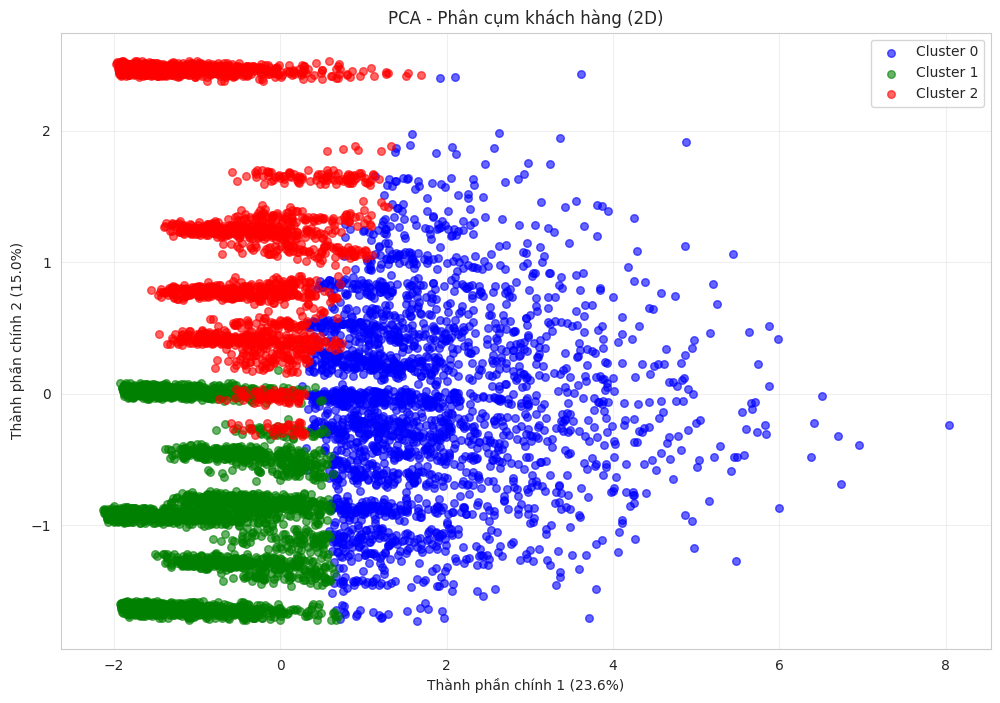

In [ ]:
from sklearn.decomposition import PCA

#Thực hiện PCA để giảm xuống 2 chiều
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Phương sai giải thích được
explained_variance_ratio = pca.explained_variance_ratio_
print("Phương sai giải thích bởi 2 thành phần chính:")
print(f"  PC1: {explained_variance_ratio[0]*100:.2f}%")
print(f"  PC2: {explained_variance_ratio[1]*100:.2f}%")
print(f"  Tổng: {(explained_variance_ratio[0]+explained_variance_ratio[1])*100:.2f}%")

# Tạo DataFrame
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = customer_df['Cluster']


# Vẽ biểu đồ phân tán 2D

plt.figure(figsize=(12, 8))
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']
# Giả sử số cụm là 3 (có thể điều chỉnh)
unique_clusters = np.unique(customer_df['Cluster'])
for i, cluster in enumerate(unique_clusters):
    subset = pca_df[pca_df['Cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'],
                c=colors[i % len(colors)],
                label=f'Cluster {cluster}',
                alpha=0.6, s=30)

plt.xlabel(f'Thành phần chính 1 ({explained_variance_ratio[0]*100:.1f}%)')
plt.ylabel(f'Thành phần chính 2 ({explained_variance_ratio[1]*100:.1f}%)')
plt.title('PCA - Phân cụm khách hàng (2D)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Phương sai giải thích bởi 3 thành phần chính:
  PC1: 23.62%
  PC2: 15.02%
  PC3: 14.78%
  Tổng: 53.42%


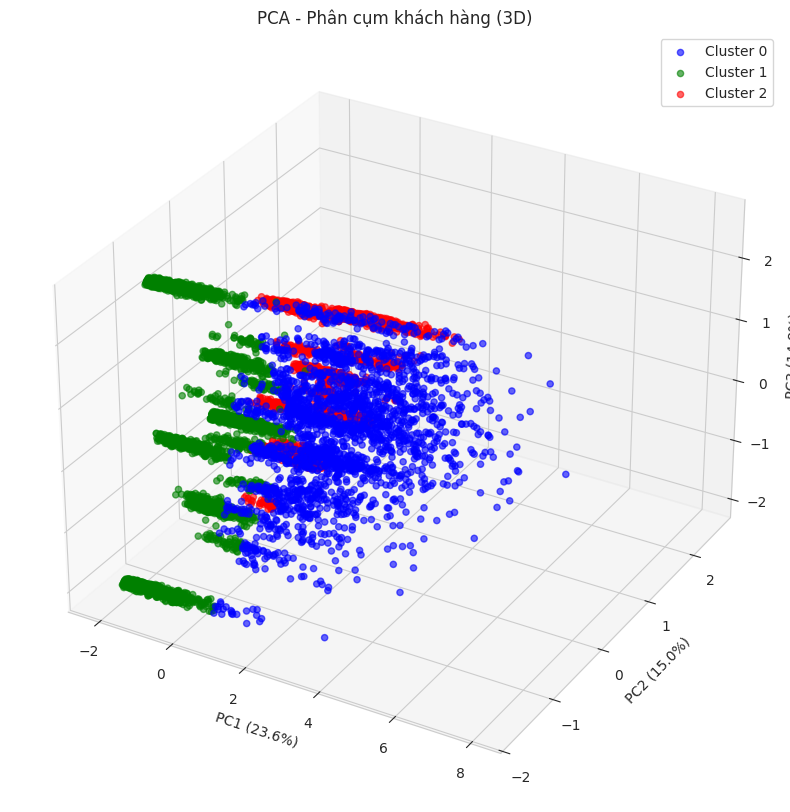

In [ ]:
# Vẽ biểu đồ 3D với 3 thành phần chính
# ------------------------------
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)
explained_3d = pca_3d.explained_variance_ratio_

print("\nPhương sai giải thích bởi 3 thành phần chính:")
print(f"  PC1: {explained_3d[0]*100:.2f}%")
print(f"  PC2: {explained_3d[1]*100:.2f}%")
print(f"  PC3: {explained_3d[2]*100:.2f}%")
print(f"  Tổng: {explained_3d.sum()*100:.2f}%")

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
for i, cluster in enumerate(unique_clusters):
    subset = X_pca_3d[customer_df['Cluster'] == cluster]
    ax.scatter(subset[:, 0], subset[:, 1], subset[:, 2],
               c=colors[i % len(colors)], label=f'Cluster {cluster}',
               alpha=0.6, s=20)

ax.set_xlabel(f'PC1 ({explained_3d[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_3d[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({explained_3d[2]*100:.1f}%)')
ax.set_title('PCA - Phân cụm khách hàng (3D)')
ax.legend()
plt.show()

3.  **Trực quan hóa Phân cụm bằng PCA:**
    *   Sử dụng PCA để giảm chiều dữ liệu xuống 2D và 3D, giúp hình dung sự phân bố của các cụm khách hàng.
    *   Biểu đồ PCA 2D cho thấy các cụm có sự chồng chéo nhất định nhưng vẫn có xu hướng tách biệt. PC1 và PC2 giải thích tổng cộng **38.64%** phương sai của dữ liệu.
    *   Biểu đồ PCA 3D cung cấp cái nhìn rõ ràng hơn về sự phân tách, với PC1, PC2, và PC3 giải thích tổng cộng **53.42%** phương sai.


Tải trọng (loadings) của các biến lên PC1 và PC2:
                               PC1       PC2
Total_Fees                0.489161 -0.022723
Total_Transaction_Amount  0.605611  0.003221
Transaction_Frequency     0.625272  0.004784
CustomerScore             0.006790 -0.016591
MonthlyIncome            -0.011224  0.020721
Pct_ATM                   0.022755  0.006452
Pct_Branch                0.018214 -0.522614
Pct_Mobile                0.003605  0.799438
Pct_Online               -0.044238 -0.294070


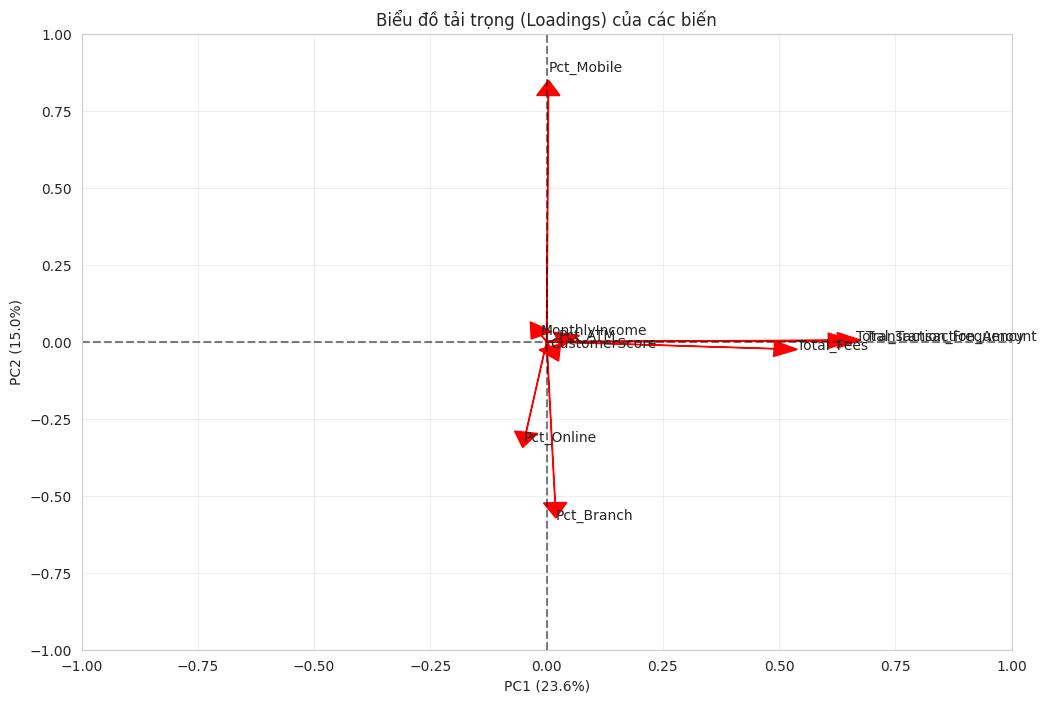

In [ ]:
# Phân tích tải trọng (loadings) của các biến lên PC1 và PC2
# Lấy tên các biến đã dùng để phân cụm
feature_names = cluster_features  # đã định nghĩa từ trước
loadings = pca.components_.T  # shape (n_features, 2)

# Tạo DataFrame loadings
loadings_df = pd.DataFrame(loadings, columns=['PC1', 'PC2'], index=feature_names)
print("\nTải trọng (loadings) của các biến lên PC1 và PC2:")
print(loadings_df)

# Vẽ biểu đồ tải trọng
plt.figure(figsize=(12, 8))
# Vẽ vector tải trọng
for i, feature in enumerate(feature_names):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1],
              head_width=0.05, head_length=0.05, fc='red', ec='red')
    plt.text(loadings[i, 0]*1.1, loadings[i, 1]*1.1, feature, fontsize=10)

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}%)')
plt.title('Biểu đồ tải trọng (Loadings) của các biến')
plt.grid(alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
plt.show()

4.  **Phân tích tải trọng (Loadings) của các biến lên PC1 và PC2:**
    *   **PC1** bị ảnh hưởng mạnh nhất bởi `Total_Fees`, `Total_Transaction_Amount` và `Transaction_Frequency`. Điều này cho thấy PC1 chủ yếu đại diện cho 'mức độ hoạt động' và 'giá trị giao dịch' của khách hàng.
    *   **PC2** có tải trọng lớn từ `Pct_Mobile` (dương mạnh) và `Pct_Branch`, `Pct_Online` (âm). Điều này chỉ ra rằng PC2 liên quan chặt chẽ đến 'hành vi sử dụng kênh' của khách hàng, đặc biệt là sự đối lập giữa sử dụng kênh Mobile và các kênh truyền thống hơn.

####Phân tích đặc điểm từng cụm


Đặc điểm trung bình của từng cụm:
         Total_Fees  Total_Transaction_Amount  Transaction_Frequency  \
Cluster                                                                
0        156.017564              22140.347883               4.071041   
1         43.715679               7887.785741               1.658862   
2         51.511718               9482.666420               2.064216   

         CustomerScore  MonthlyIncome   Pct_ATM  Pct_Branch  Pct_Mobile  \
Cluster                                                                   
0           578.365650    5444.253326  0.258334    0.261039    0.239738   
1           575.518672    5415.544920  0.315032    0.341484    0.000593   
2           572.926041    5522.617604  0.112673    0.106451    0.669221   

         Pct_Online  
Cluster              
0          0.240889  
1          0.342892  
2          0.111655  


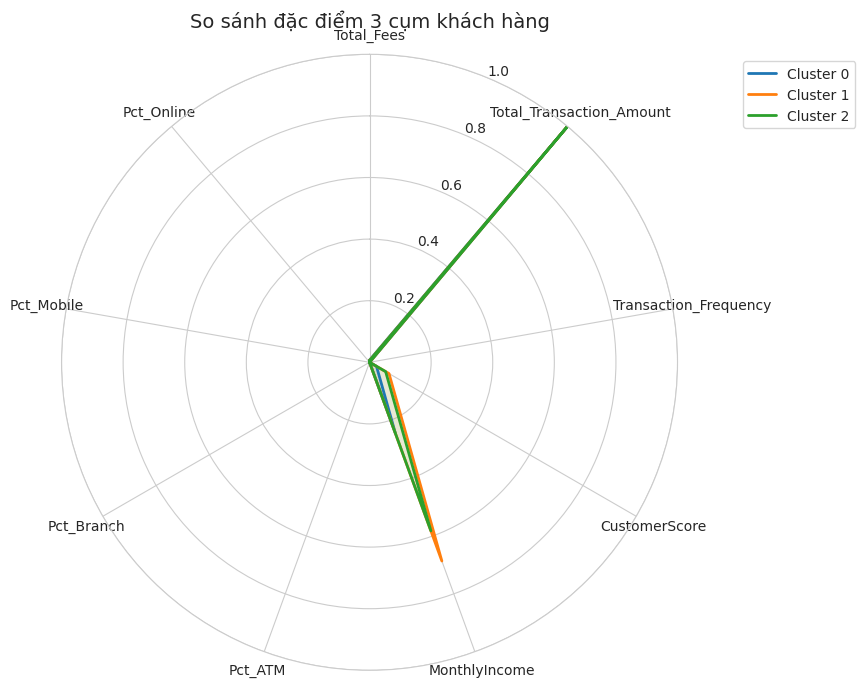

In [ ]:
# Tổng hợp trung bình các biến theo cụm
cluster_profile = customer_df.groupby('Cluster')[cluster_features].mean()
print("\nĐặc điểm trung bình của từng cụm:")
print(cluster_profile)

# Vẽ biểu đồ radar (chuẩn hóa MinMax để so sánh)
from sklearn.preprocessing import MinMaxScaler
scaler_radar = MinMaxScaler()
profile_normalized = scaler_radar.fit_transform(cluster_profile.T).T
profile_normalized_df = pd.DataFrame(profile_normalized, columns=cluster_profile.columns, index=cluster_profile.index)

def radar_chart(data, title):
    categories = data.columns.tolist()
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    for i in data.index:
        values = data.loc[i].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=f'Cluster {i}')
        ax.fill(angles, values, alpha=0.1)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title(title, size=14, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.show()

radar_chart(profile_normalized_df, 'So sánh đặc điểm 3 cụm khách hàng')

####Xác định các loại cụm dựa trên đặc điểm

In [ ]:
# Bổ sung biến rủi ro (Has_Late_Payment)
if 'Has_Late_Payment' not in customer_df.columns:
    customer_df['Has_Late_Payment'] = 0  # placeholder

# Tổng hợp chi tiết từng cụm
cluster_summary = customer_df.groupby('Cluster').agg(
    So_luong_khach=('CustomerID', 'count'),
    Tong_phi_trung_binh=('Total_Fees', 'mean'),
    Tong_tien_trung_binh=('Total_Transaction_Amount', 'mean'),
    Tan_suat_trung_binh=('Transaction_Frequency', 'mean'),
    Diem_tin_dung_trung_binh=('CustomerScore', 'mean'),
    Thu_nhap_trung_binh=('MonthlyIncome', 'mean'),
    Ty_le_ATM=('Pct_ATM', 'mean'),
    Ty_le_Mobile=('Pct_Mobile', 'mean'),
    Ty_le_Branch=('Pct_Branch', 'mean'),
    Ty_le_Online=('Pct_Online', 'mean'),
    Ty_le_co_phai_tre=('Has_Late_Payment', 'mean')
).reset_index()

print("\nBảng tổng hợp chi tiết từng cụm (k=3):")
print(cluster_summary)

# ------------------------------
# GÁN NHÃN (dựa trên đặc điểm thực tế)
# ------------------------------
cluster_labels = {}

for c in cluster_summary['Cluster']:
    row = cluster_summary[cluster_summary['Cluster'] == c].iloc[0]

    # Ưu tiên: cụm có tỷ lệ mobile > 60% -> Cụm thiên về Mobile
    if row['Ty_le_Mobile'] > 0.6:
        label = 'Cụm thiên về Mobile'
    # Cụm có tổng tiền và tần suất cao nhất -> Cụm sinh lợi cao
    elif row['Tong_tien_trung_binh'] == cluster_summary['Tong_tien_trung_binh'].max():
        label = 'Cụm sinh lợi cao (giá trị lớn, tần suất cao)'
    # Còn lại -> Cụm truyền thống (branch/online)
    else:
        label = 'Cụm truyền thống (branch/online)'

    cluster_labels[c] = label

# Gán nhãn vào DataFrame
customer_df['Cluster_Label'] = customer_df['Cluster'].map(cluster_labels)

print("\nNhãn phân loại các cụm:")
for c, label in cluster_labels.items():
    print(f"  Cluster {c}: {label}")

# Kiểm tra phân bố
print("\nPhân bố khách hàng theo nhãn:")
print(customer_df['Cluster_Label'].value_counts())


Bảng tổng hợp chi tiết từng cụm (k=3):
   Cluster  So_luong_khach  Tong_phi_trung_binh  Tong_tien_trung_binh  \
0        0            2393           156.017564          22140.347883   
1        1            3374            43.715679           7887.785741   
2        2            2258            51.511718           9482.666420   

   Tan_suat_trung_binh  Diem_tin_dung_trung_binh  Thu_nhap_trung_binh  \
0             4.071041                578.365650          5444.253326   
1             1.658862                575.518672          5415.544920   
2             2.064216                572.926041          5522.617604   

   Ty_le_ATM  Ty_le_Mobile  Ty_le_Branch  Ty_le_Online  Ty_le_co_phai_tre  
0   0.258334      0.239738      0.261039      0.240889           0.613038  
1   0.315032      0.000593      0.341484      0.342892           0.220510  
2   0.112673      0.669221      0.106451      0.111655           0.255979  

Nhãn phân loại các cụm:
  Cluster 0: Cụm sinh lợi cao (giá trị lớn, t

### Nhận xét về phân tích đặc điểm từng cụm

Sau khi gán nhãn cho 3 cụm khách hàng, chúng ta có thể phân tích sâu hơn về đặc điểm và hành vi của từng nhóm:

**1. Cụm sinh lợi cao (giá trị lớn, tần suất cao) - Cluster 0:**
*   **Số lượng:** 2393 khách hàng.
*   **Đặc điểm nổi bật:** Đây là nhóm khách hàng giá trị nhất, với tổng phí trung bình cao nhất (156.02 EUR), tổng giá trị giao dịch và tần suất giao dịch cao nhất (22140.35 EUR và 4.07 giao dịch/khách hàng).
*   **Rủi ro/Hành vi đặc biệt:** Tỷ lệ khách hàng có phí phạt trả chậm cao nhất (61.30%), cho thấy mặc dù họ sinh lời cao, nhưng cũng tiềm ẩn rủi ro về khả năng quản lý tài chính hoặc cần được hỗ trợ để tránh các khoản phí này.
*   **Kênh sử dụng:** Phân bổ khá đồng đều giữa các kênh, không có kênh nào vượt trội rõ rệt.

**2. Cụm truyền thống (branch/online) - Cluster 1:**
*   **Số lượng:** 3374 khách hàng (chiếm tỷ lệ lớn nhất).
*   **Đặc điểm nổi bật:** Nhóm này có tổng phí trung bình thấp nhất (43.72 EUR), tổng giá trị giao dịch và tần suất giao dịch cũng thấp nhất (7887.79 EUR và 1.66 giao dịch/khách hàng).
*   **Hành vi đặc biệt:** Sử dụng kênh Branch (chi nhánh) và Online nhiều nhất, và gần như không sử dụng kênh Mobile (0.06%). Tỷ lệ có phí phạt trả chậm thấp nhất (22.05%).
*   **Tiềm năng:** Mặc dù hiện tại sinh lời thấp, đây là nhóm khách hàng lớn, có thể được khuyến khích giao dịch nhiều hơn và chuyển đổi sang các kênh số tiện lợi hơn.

**3. Cụm thiên về Mobile - Cluster 2:**
*   **Số lượng:** 2258 khách hàng.
*   **Đặc điểm nổi bật:** Tổng phí trung bình và tổng giá trị giao dịch ở mức trung bình (51.51 EUR và 9482.67 EUR), tần suất giao dịch cũng ở mức trung bình (2.06 giao dịch/khách hàng).
*   **Hành vi đặc biệt:** Điểm nhấn của cụm này là tỷ lệ sử dụng kênh Mobile vượt trội (66.92%), cho thấy họ là những người dùng tích cực công nghệ. Tỷ lệ có phí phạt trả chậm ở mức thấp (25.60%).
*   **Tiềm năng:** Nhóm này có thể là mục tiêu lý tưởng cho các sản phẩm và dịch vụ ngân hàng số mới, cũng như các chiến dịch marketing qua kênh di động.

**Tổng kết:**
Phân cụm đã giúp ngân hàng xác định được 3 nhóm khách hàng khác biệt về hành vi giao dịch, khả năng sinh lời và cách thức sử dụng kênh. Điều này là cơ sở quan trọng để xây dựng các chiến lược chăm sóc khách hàng, phát triển sản phẩm và marketing cá nhân hóa hiệu quả hơn.


Tổng giá trị giao dịch theo từng loại cụm:
Cluster_Label
Cụm sinh lợi cao (giá trị lớn, tần suất cao)    5.298185e+07
Cụm truyền thống (branch/online)                2.661339e+07
Cụm thiên về Mobile                             2.141186e+07
Name: Total_Transaction_Amount, dtype: float64

Tần suất giao dịch trung bình theo từng loại cụm:
Cluster_Label
Cụm sinh lợi cao (giá trị lớn, tần suất cao)    4.071041
Cụm thiên về Mobile                             2.064216
Cụm truyền thống (branch/online)                1.658862
Name: Transaction_Frequency, dtype: float64


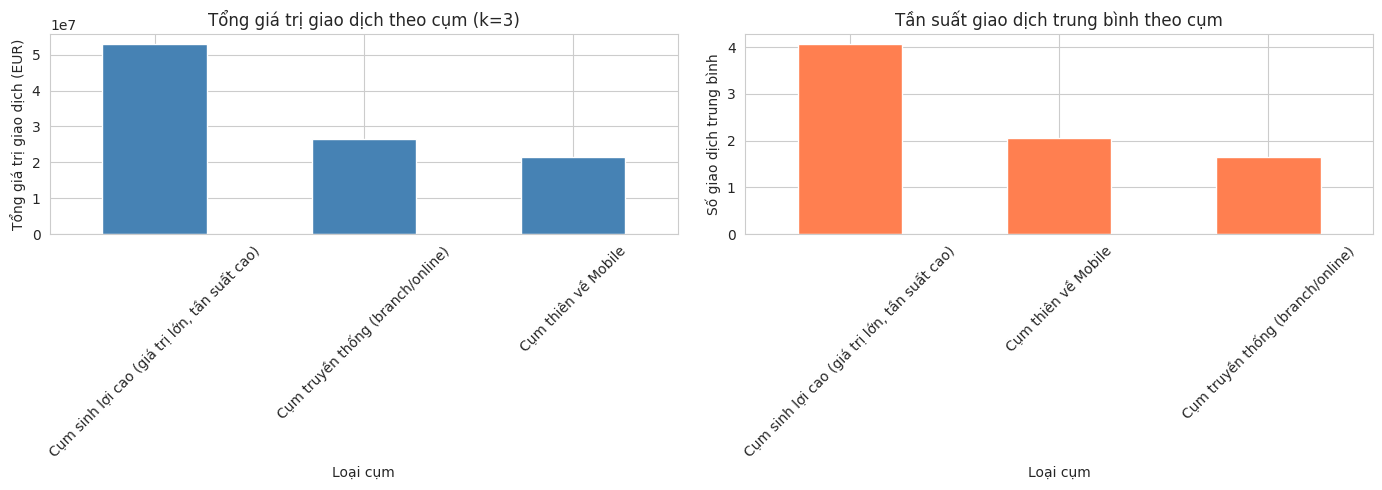

In [ ]:
# So sánh tổng giá trị giao dịch theo cụm
amount_by_cluster = customer_df.groupby('Cluster_Label')['Total_Transaction_Amount'].sum().sort_values(ascending=False)
print("\nTổng giá trị giao dịch theo từng loại cụm:")
print(amount_by_cluster)

# So sánh tần suất giao dịch trung bình theo cụm
frequency_by_cluster = customer_df.groupby('Cluster_Label')['Transaction_Frequency'].mean().sort_values(ascending=False)
print("\nTần suất giao dịch trung bình theo từng loại cụm:")
print(frequency_by_cluster)

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ tổng giá trị giao dịch
amount_by_cluster.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Tổng giá trị giao dịch theo cụm (k=3)')
axes[0].set_ylabel('Tổng giá trị giao dịch (EUR)')
axes[0].set_xlabel('Loại cụm')
axes[0].tick_params(axis='x', rotation=45)

# Biểu đồ tần suất giao dịch trung bình
frequency_by_cluster.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Tần suất giao dịch trung bình theo cụm')
axes[1].set_ylabel('Số giao dịch trung bình')
axes[1].set_xlabel('Loại cụm')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Xét về tổng giá trị giao dịch, Cụm sinh lợi cao đóng góp khoảng 52,98 triệu EUR – cao gần gấp đôi so với Cụm truyền thống (26,61 triệu EUR) và hơn đáng kể so với Cụm Mobile (21,41 triệu EUR). Đồng thời, tần suất giao dịch trung bình của nhóm này cũng vượt trội (4,07 lần), củng cố vai trò là phân khúc khách hàng chiến lược về mặt doanh thu.

In [ ]:
# Lưu kết quả phân cụm

customer_df.to_csv('customer_clusters.csv', index=False)
print("\nĐã lưu kết quả phân cụm vào file customer_clusters.csv")


Đã lưu kết quả phân cụm vào file customer_clusters.csv


##2.3. Xây dựng mô hình phân loại dự báo khả năng sinh lợi (Classification)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, auc
)

# Đọc dữ liệu đã phân cụm
customer_df = pd.read_csv('customer_clusters.csv')

print("Kích thước dữ liệu:", customer_df.shape)
customer_df.head()

Kích thước dữ liệu: (8025, 16)


,CustomerID,Total_Fees,Total_Transaction_Amount,Transaction_Frequency,Avg_Transaction_Amount,Total_Insurance_Fees,Has_Late_Payment,MonthlyIncome,CustomerScore,Segment_Code,Pct_ATM,Pct_Branch,Pct_Mobile,Pct_Online,Cluster,Cluster_Label
0,1000,37.09,9299.404668,1,9299.404668,0.00,0,2434.25,399.0,0,1.000000,0.000000,0.0,0.0,1,Cụm truyền thống (branch/online)
1,1001,134.65,15570.797370,5,3114.159474,134.65,0,2606.21,393.0,0,0.400000,0.200000,0.2,0.2,0,"Cụm sinh lợi cao (giá trị lớn, tần suất cao)"
2,1002,31.96,14090.472326,2,7045.236163,31.96,0,4044.38,648.0,1,0.000000,0.500000,0.0,0.5,1,Cụm truyền thống (branch/online)
3,1003,4.29,5211.016894,1,5211.016894,4.29,0,4615.51,821.0,1,0.000000,1.000000,0.0,0.0,1,Cụm truyền thống (branch/online)
4,1004,17.24,23102.043711,3,7700.681237,17.24,0,6546.14,589.0,1,0.333333,0.666667,0.0,0.0,0,"Cụm sinh lợi cao (giá trị lớn, tần suất cao)"


In [ ]:
# Tạo biến mục tiêu: High_profit_customer

median_fee = customer_df['Total_Fees'].median()

customer_df['High_profit_customer'] = np.where(
    customer_df['Total_Fees'] > median_fee, 1, 0
)

print("\nTrung vị tổng phí:", median_fee)
print("\nPhân bố biến mục tiêu:")
print(customer_df['High_profit_customer'].value_counts(normalize=True)*100)


Trung vị tổng phí: 47.29

Phân bố biến mục tiêu:
High_profit_customer
0    50.006231
1    49.993769
Name: proportion, dtype: float64


####2.3.2. Chuẩn bị dữ liệu huấn luyện

In [ ]:
# Chọn biến độc lập

feature_cols = [
    'Total_Transaction_Amount',
    'Transaction_Frequency',
    'Avg_Transaction_Amount',
    'CustomerScore',
    'MonthlyIncome',
    'Pct_ATM',
    'Pct_Mobile',
    'Pct_Branch',
    'Pct_Online',
    'Cluster'  # thêm cụm vào mô hình
]

X = customer_df[feature_cols]
y = customer_df['High_profit_customer']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5617, 10)
Test size: (2408, 10)


####2.3.3. Huấn luyện mô hình

#####Logistic Regression

In [ ]:
# Chuẩn hóa dữ liệu cho Logistic Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Khởi tạo mô hình
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Huấn luyện
lr_model.fit(X_train_scaled, y_train)

# Dự đoán
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# Đánh giá
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== Logistic Regression ===
Accuracy: 0.7006
ROC-AUC: 0.7548

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.85      0.74      1204
           1       0.79      0.55      0.65      1204

    accuracy                           0.70      2408
   macro avg       0.72      0.70      0.69      2408
weighted avg       0.72      0.70      0.69      2408



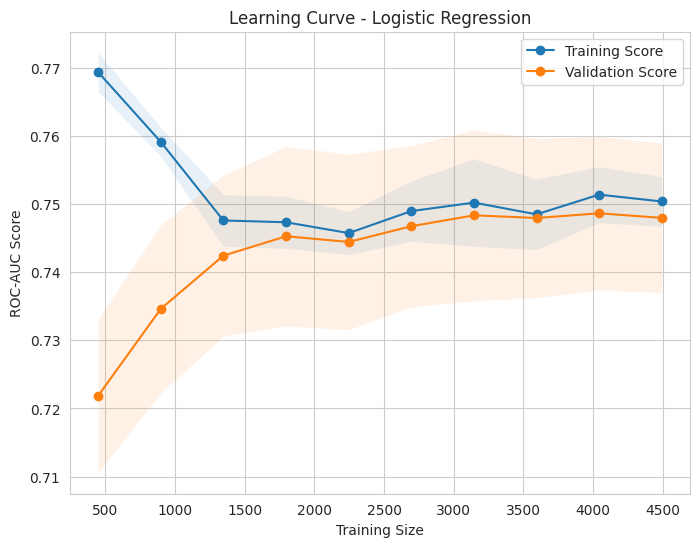

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

# Dùng dữ liệu đã scale
train_sizes, train_scores, val_scores = learning_curve(
    lr_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

# Tính trung bình và độ lệch chuẩn
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Vẽ biểu đồ
plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
plt.plot(train_sizes, val_mean, 'o-', label='Validation Score')

plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1)

plt.xlabel('Training Size')
plt.ylabel('ROC-AUC Score')
plt.title('Learning Curve - Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

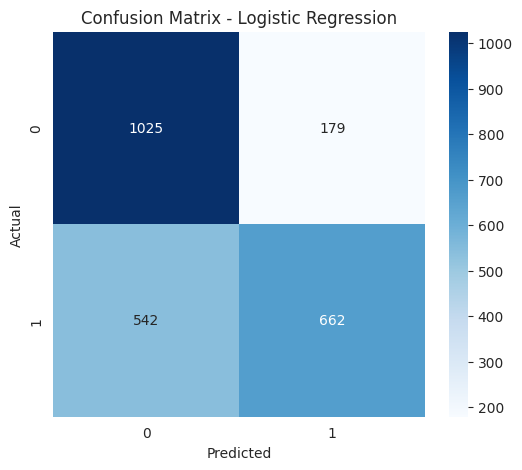

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

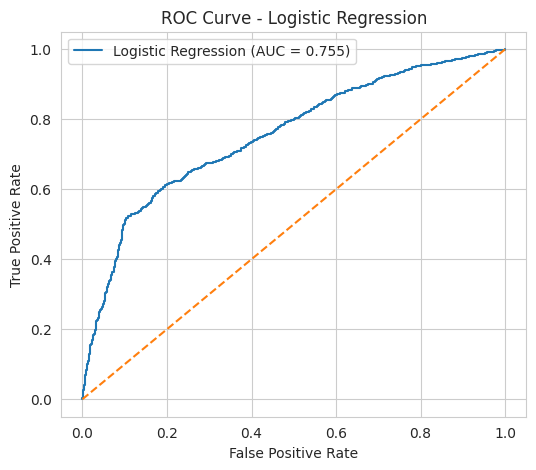

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

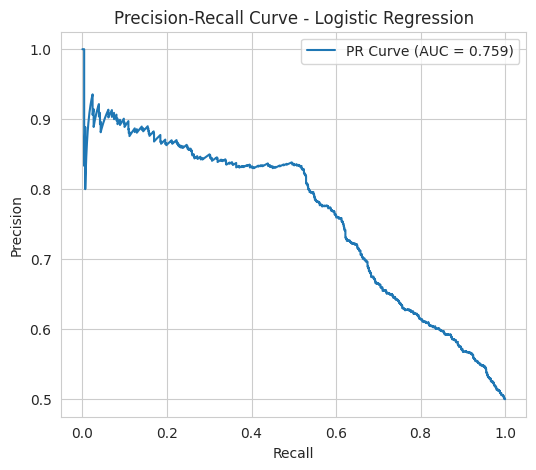

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

#####Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Khởi tạo mô hình
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    max_depth=10,  # Giới hạn độ sâu tối đa của cây
    min_samples_leaf=5, # Yêu cầu tối thiểu 5 mẫu trong một nút lá
    n_jobs=-1
)

# Huấn luyện
rf_model.fit(X_train, y_train)

# Dự đoán
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Đánh giá
accuracy_rf = accuracy_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("=== Random Forest (Baseline) ===")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"ROC-AUC: {roc_auc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

=== Random Forest (Baseline) ===
Accuracy: 0.7056
ROC-AUC: 0.7721

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.82      0.74      1204
           1       0.77      0.59      0.67      1204

    accuracy                           0.71      2408
   macro avg       0.72      0.71      0.70      2408
weighted avg       0.72      0.71      0.70      2408



In [ ]:
from sklearn.model_selection import GridSearchCV

# Định nghĩa lưới các tham số cần tìm kiếm đã giảm bớt để tăng tốc độ
param_grid_rf = {
    'n_estimators': [100, 200],  # Giảm số lượng
    'max_depth': [10, 15],  # Giảm số lượng
    'min_samples_split': [5, 10], # Giảm số lượng
    'min_samples_leaf': [3, 5],   # Giảm số lượng
    'max_features': ['sqrt', 'log2'] # Giữ nguyên
}

# Khởi tạo mô hình Random Forest cơ bản
rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Khởi tạo GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=5, # Sử dụng 5-fold cross-validation
    scoring='roc_auc', # Tối ưu hóa theo ROC-AUC
    n_jobs=-1, # Sử dụng tất cả các CPU cores
    verbose=1 # Hiển thị tiến độ
)

print("Bắt đầu quá trình tìm kiếm siêu tham số...")
# Thực hiện tìm kiếm siêu tham số
grid_search_rf.fit(X_train, y_train)

print("\nKết thúc tìm kiếm siêu tham số.")

# In ra các tham số tốt nhất và điểm số tương ứng
print("Các tham số tốt nhất:", grid_search_rf.best_params_)
print("ROC-AUC tốt nhất trên tập validation:", grid_search_rf.best_score_)

# Lấy mô hình tối ưu
rf_best_model = grid_search_rf.best_estimator_


Bắt đầu quá trình tìm kiếm siêu tham số...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Kết thúc tìm kiếm siêu tham số.
Các tham số tốt nhất: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 200}
ROC-AUC tốt nhất trên tập validation: 0.7705667203518711


#####Đánh giá mô hình Random Forest tối ưu

In [ ]:
# Dự đoán trên tập kiểm tra với mô hình tối ưu
y_pred_opt = rf_best_model.predict(X_test)
y_prob_opt = rf_best_model.predict_proba(X_test)[:, 1]

# Đánh giá
accuracy_opt = accuracy_score(y_test, y_pred_opt)
roc_auc_opt = roc_auc_score(y_test, y_prob_opt)

print("=== Random Forest (Optimized) ===")
print(f"Accuracy: {accuracy_opt:.4f}")
print(f"ROC-AUC: {roc_auc_opt:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_opt))

=== Random Forest (Optimized) ===
Accuracy: 0.7072
ROC-AUC: 0.7716

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.82      0.74      1204
           1       0.77      0.59      0.67      1204

    accuracy                           0.71      2408
   macro avg       0.72      0.71      0.70      2408
weighted avg       0.72      0.71      0.70      2408



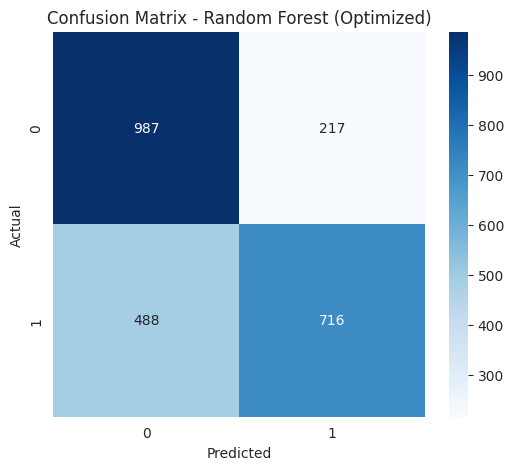

In [ ]:
# Confusion Matrix
cm_opt = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest (Optimized)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

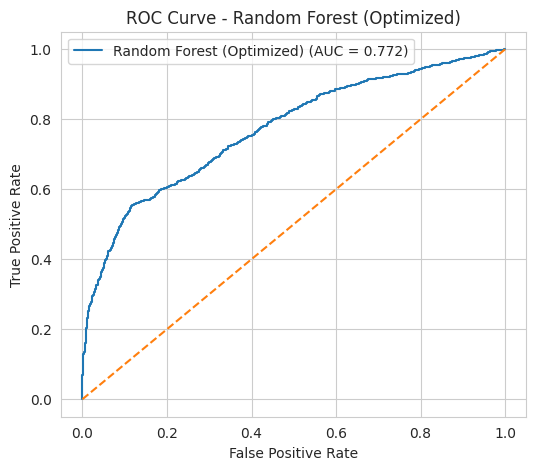

In [ ]:
# ROC Curve
fpr_opt, tpr_opt, _ = roc_curve(y_test, y_prob_opt)
plt.figure(figsize=(6, 5))
plt.plot(fpr_opt, tpr_opt, label=f'Random Forest (Optimized) (AUC = {roc_auc_opt:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (Optimized)')
plt.legend()
plt.grid(True)
plt.show()

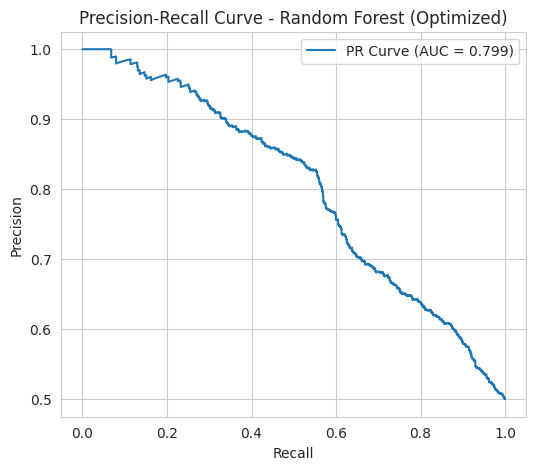

In [ ]:
# Precision-Recall Curve
precision_opt, recall_opt, _ = precision_recall_curve(y_test, y_prob_opt)
pr_auc_opt = auc(recall_opt, precision_opt)
plt.figure(figsize=(6, 5))
plt.plot(recall_opt, precision_opt, label=f'PR Curve (AUC = {pr_auc_opt:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Random Forest (Optimized)')
plt.legend()
plt.grid(True)
plt.show()

#####Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np

# Tạo pipeline
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),   # Có thể bỏ nếu không cần
    ('gb', GradientBoostingClassifier(random_state=42))
])

# Grid search tham số
param_grid = {
    'gb__n_estimators': [100, 200],
    'gb__learning_rate': [0.05, 0.1],
    'gb__max_depth': [3, 4],
    'gb__min_samples_leaf': [1, 5]
}

grid_search = GridSearchCV(
    gb_pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Huấn luyện
grid_search.fit(X_train, y_train)

# Best model
best_gb = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'gb__learning_rate': 0.05, 'gb__max_depth': 4, 'gb__min_samples_leaf': 5, 'gb__n_estimators': 100}


In [ ]:
# Dự đoán
y_pred = best_gb.predict(X_test)
y_prob = best_gb.predict_proba(X_test)[:, 1]

# Đánh giá
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n=== Gradient Boosting ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


=== Gradient Boosting ===
Accuracy: 0.7139
ROC-AUC: 0.7716

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.86      0.75      1204
           1       0.80      0.57      0.67      1204

    accuracy                           0.71      2408
   macro avg       0.73      0.71      0.71      2408
weighted avg       0.73      0.71      0.71      2408



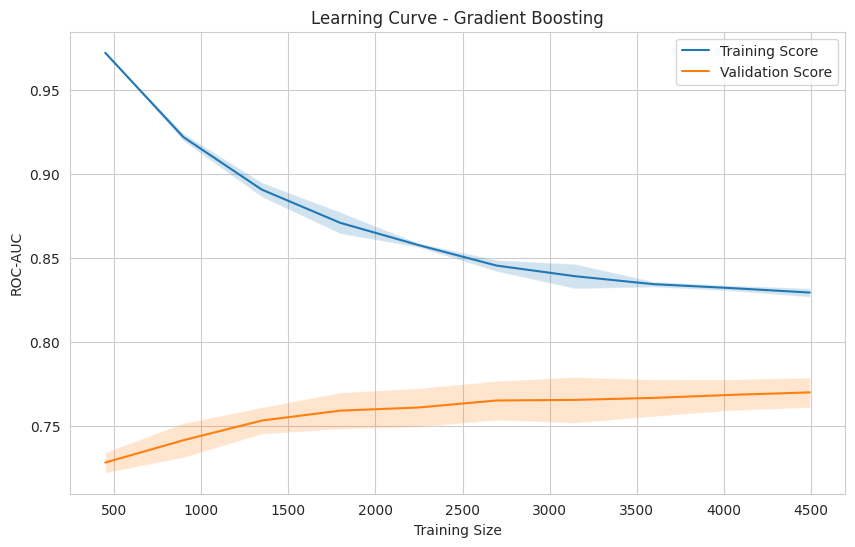

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Nếu bạn đã có best_gb từ GridSearch
gb_model = best_gb

train_sizes, train_scores, val_scores = learning_curve(
    gb_model,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Trung bình & độ lệch chuẩn
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Vẽ biểu đồ
plt.figure(figsize=(10,6))

plt.plot(train_sizes, train_mean, label="Training Score")
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.2)

plt.plot(train_sizes, val_mean, label="Validation Score")
plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.2)

plt.xlabel("Training Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve - Gradient Boosting")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 600x500 with 0 Axes>

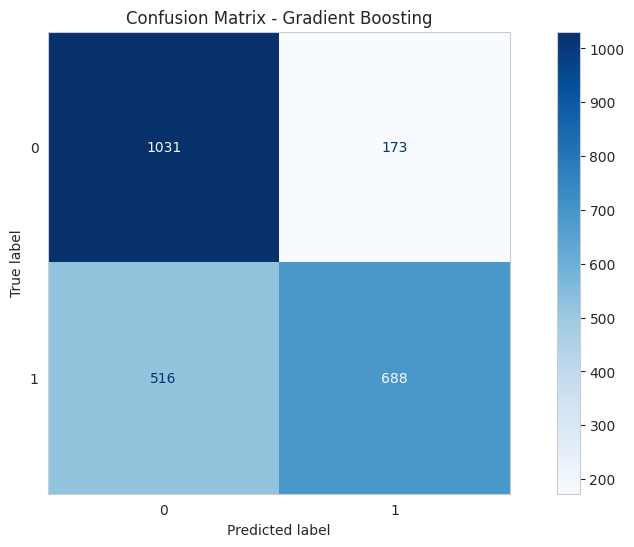

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Dự đoán
y_pred = best_gb.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Gradient Boosting")
plt.grid(False)
plt.show()

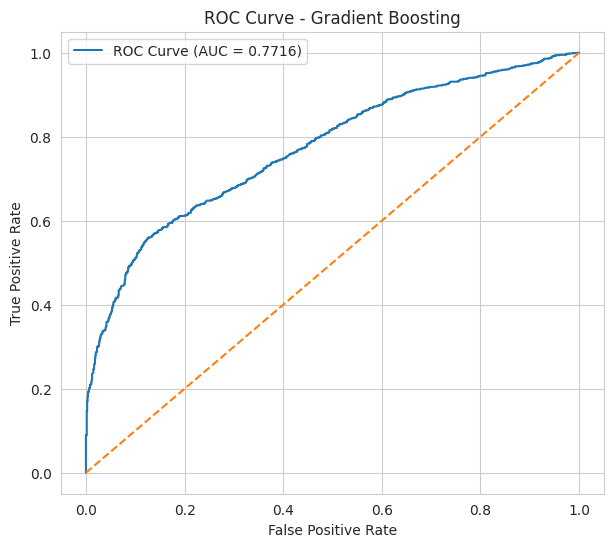

In [ ]:
from sklearn.metrics import roc_curve, auc

# Xác suất
y_prob = best_gb.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.grid(True)
plt.show()

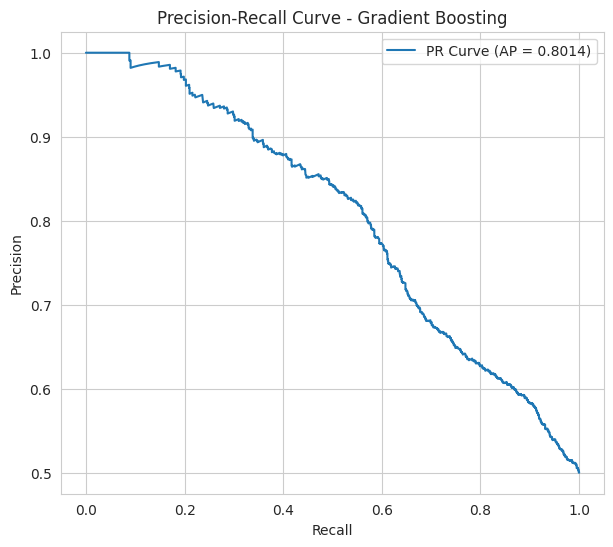

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Xác suất dự đoán lớp 1
y_prob = best_gb.predict_proba(X_test)[:, 1]

# Tính precision, recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Average Precision (AP)
ap_score = average_precision_score(y_test, y_prob)

# Vẽ biểu đồ
plt.figure(figsize=(7,6))
plt.plot(recall, precision, label=f"PR Curve (AP = {ap_score:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Gradient Boosting")
plt.legend()
plt.grid(True)
plt.show()

####So sánh mô hình

In [ ]:
# ==============================
# SO SÁNH MÔ HÌNH CHUẨN
# ==============================

from sklearn.metrics import (
    accuracy_score, recall_score,
    precision_score, f1_score,
    roc_auc_score, confusion_matrix
)

# ======================
# 1. Logistic Regression
# ======================
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

accuracy_lr = accuracy_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

# ======================
# 2. Random Forest
# ======================
y_pred_rf = rf_best_model.predict(X_test)
y_prob_rf = rf_best_model.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# ======================
# 3. Gradient Boosting
# ======================
y_pred_gb = best_gb.predict(X_test)
y_prob_gb = best_gb.predict_proba(X_test)[:, 1]

accuracy_gb = accuracy_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_prob_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

# ======================
# TẠO BẢNG SO SÁNH
# ======================

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [accuracy_lr, accuracy_rf, accuracy_gb],
    "ROC-AUC": [roc_auc_lr, roc_auc_rf, roc_auc_gb],
    "Precision": [precision_lr, precision_rf, precision_gb],
    "Recall": [recall_lr, recall_rf, recall_gb],
    "F1-Score": [f1_lr, f1_rf, f1_gb]
})

comparison_df

,Model,Accuracy,ROC-AUC,Precision,Recall,F1-Score
0,Logistic Regression,0.700581,0.754799,0.787158,0.549834,0.647433
1,Random Forest,0.707226,0.771562,0.767417,0.594684,0.670098
2,Gradient Boosting,0.713870,0.771647,0.799071,0.571429,0.666344


Xét theo Accuracy, mô hình Gradient Boosting đạt giá trị cao nhất (0,771647), vượt trội so với Logistic Regression (0,713870) và Random Forest (0,707226). Điều này cho thấy Gradient Boosting có tỷ lệ dự đoán đúng tổng thể cao hơn.

Về ROC-AUC, cả ba mô hình đều đạt mức xấp xỉ 0,77 và gần như tương đương nhau (≈ 0,7716). Kết quả này hàm ý rằng khả năng phân biệt giữa hai lớp (khách hàng sinh lời cao và không sinh lời cao) của ba mô hình là tương đương về mặt tổng thể, không có sự khác biệt đáng kể về năng lực phân loại.

Đối với Precision, Logistic Regression và Gradient Boosting cùng đạt giá trị cao nhất (0,799071), trong khi Random Forest thấp hơn đôi chút (0,767417). Điều này cho thấy hai mô hình đầu có tỷ lệ dự đoán đúng cao hơn trong số các khách hàng được gán nhãn “sinh lời cao”, tức là giảm thiểu tốt hơn các dự đoán dương tính giả.

Tuy nhiên, xét theo Recall – chỉ số đặc biệt quan trọng trong bối cảnh mục tiêu kinh doanh là không bỏ sót khách hàng sinh lời cao – Random Forest đạt giá trị cao nhất (0,594684), cao hơn Logistic Regression và Gradient Boosting (0,571429). Điều này cho thấy Random Forest có khả năng phát hiện khách hàng sinh lời cao tốt hơn, tức giảm thiểu sai sót loại II (false negatives).

Cuối cùng, xét theo F1-score, Random Forest đạt 0,670098 – cao nhất trong ba mô hình – phản ánh sự cân bằng tối ưu giữa Precision và Recall. Trong khi đó, Logistic Regression và Gradient Boosting cùng đạt 0,666344, thấp hơn một mức nhỏ.


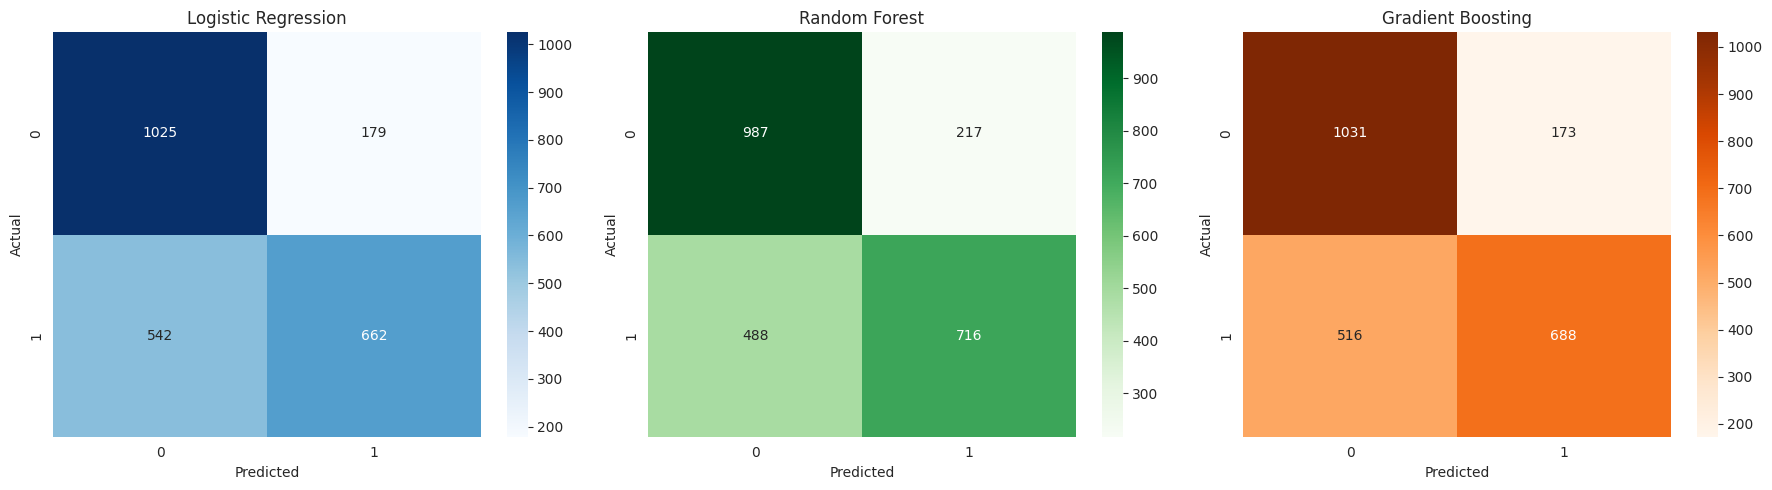

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Logistic
sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Gradient Boosting
sns.heatmap(confusion_matrix(y_test, y_pred_gb),
            annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title("Gradient Boosting")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

Logistic Regression: Mô hình dự đoán đúng 1.031 khách hàng thuộc lớp không sinh lời cao và 688 khách hàng sinh lời cao. Tồn tại 173 trường hợp dương tính giả và 516 trường hợp âm tính giả. Điều này cho thấy mô hình có xu hướng bỏ sót một lượng đáng kể khách hàng sinh lời cao.

Random Forest: Số lượng True Positive tăng lên 716 và False Negative giảm xuống 488, phản ánh khả năng nhận diện lớp khách hàng sinh lời cao được cải thiện. Tuy nhiên, số False Positive tăng lên 217, cho thấy mô hình có xu hướng mạnh tay hơn trong việc dự đoán lớp dương, dẫn đến gia tăng cảnh báo sai.

Gradient Boosting: Ma trận nhầm lẫn của Gradient Boosting gần tương đồng với Logistic Regression (True Negative = 1.031, False Positive = 173, False Negative = 516, True Positive = 688), cho thấy khả năng phân loại hai lớp ở mức trung bình và chưa tạo ra sự cải thiện rõ rệt về khả năng phát hiện lớp dương.


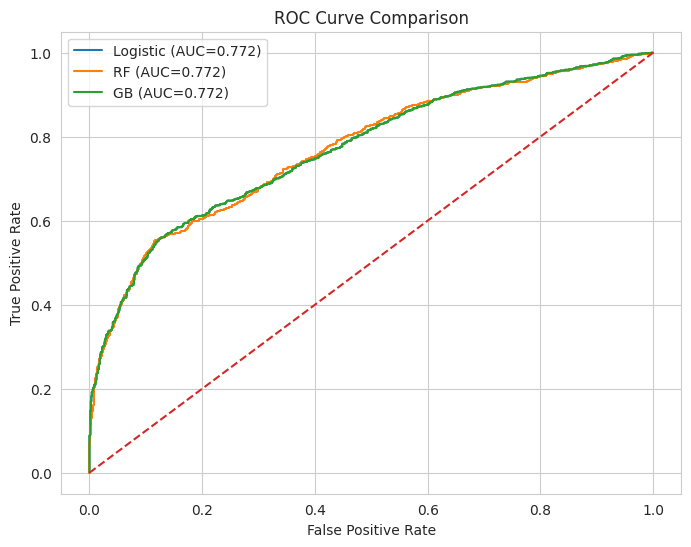

In [ ]:
#ROC Curve chung 3 mô hình
plt.figure(figsize=(8,6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic (AUC={roc_auc:.3f})")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_opt)
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={roc_auc_opt:.3f})")

# Gradient Boosting
y_prob_gb = best_gb.predict_proba(X_test)[:,1]
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
roc_auc_gb = roc_auc_score(y_test, y_prob_gb)
plt.plot(fpr_gb, tpr_gb, label=f"GB (AUC={roc_auc_gb:.3f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

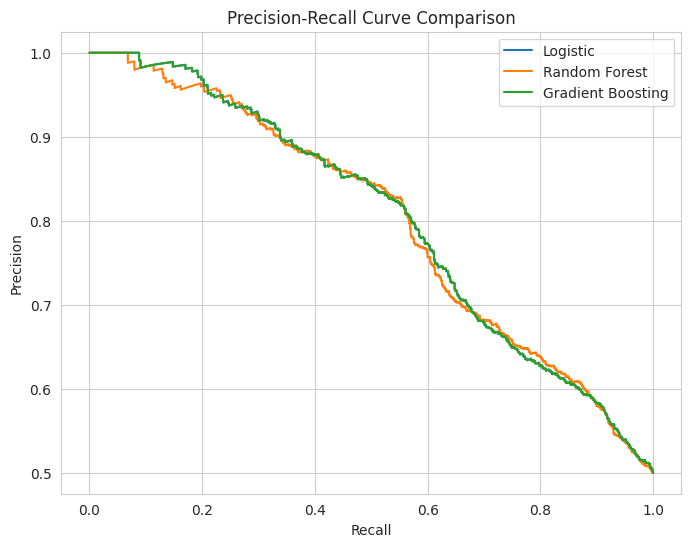

In [ ]:
#Precision–Recall Curve chung
plt.figure(figsize=(8,6))

# Logistic
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall_lr, precision_lr, label="Logistic")

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_opt)
plt.plot(recall_rf, precision_rf, label="Random Forest")

# Gradient Boosting
precision_gb, recall_gb, _ = precision_recall_curve(y_test, y_prob_gb)
plt.plot(recall_gb, precision_gb, label="Gradient Boosting")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

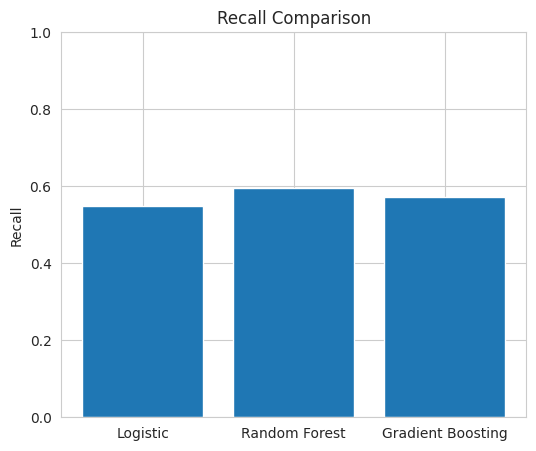

In [ ]:
#So sánh Recall trực quan
plt.figure(figsize=(6,5))

# Lấy các giá trị recall từ comparison_df để đảm bảo chúng là các giá trị scalar
recall_lr_scalar = comparison_df[comparison_df['Model'] == 'Logistic Regression']['Recall'].values[0]
recall_rf_scalar = comparison_df[comparison_df['Model'] == 'Random Forest']['Recall'].values[0]
recall_gb_scalar = comparison_df[comparison_df['Model'] == 'Gradient Boosting']['Recall'].values[0]

plt.bar(["Logistic", "Random Forest", "Gradient Boosting"],
        [recall_lr_scalar, recall_rf_scalar, recall_gb_scalar])
plt.ylim(0,1)
plt.title("Recall Comparison")
plt.ylabel("Recall")
plt.show()

In [ ]:
best_model_recall = comparison_df.sort_values(by="Recall", ascending=False).iloc[0]["Model"]

print("====================================")
print(f"MÔ HÌNH TỐT NHẤT THEO RECALL: {best_model_recall}")
print("====================================")

MÔ HÌNH TỐT NHẤT THEO RECALL: Random Forest


In [ ]:
if best_model_recall == "Logistic Regression":
    final_model = lr_model
elif best_model_recall == "Random Forest":
    final_model = rf_best_model
else:
    final_model = best_gb

print("Final model ready for deployment:", best_model_recall)

Final model ready for deployment: Random Forest


###2.3.4. Phân tích yếu tố ảnh hưởng

=== FEATURE IMPORTANCE - RANDOM FOREST ===
                    Feature  Importance
0                   Cluster    0.295712
1  Total_Transaction_Amount    0.180686
2     Transaction_Frequency    0.135861
3    Avg_Transaction_Amount    0.110580
4             MonthlyIncome    0.087638
5             CustomerScore    0.083143
6                Pct_Mobile    0.032058
7                Pct_Branch    0.029380
8                   Pct_ATM    0.023591
9                Pct_Online    0.021352


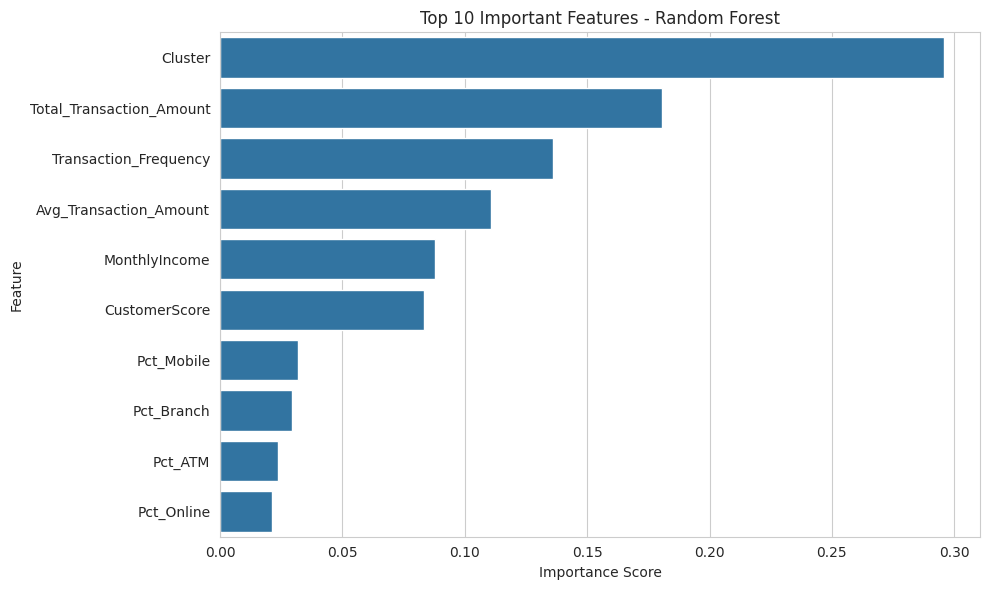

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Lấy độ quan trọng của biến
importances = rf_best_model.feature_importances_

# Tạo DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

# Sắp xếp giảm dần
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("=== FEATURE IMPORTANCE - RANDOM FOREST ===")
print(feature_importance_df)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Biến Cluster có mức độ quan trọng cao nhất (0,295712), vượt trội so với các biến còn lại. Điều này cho thấy phân khúc khách hàng đóng vai trò trung tâm trong việc dự báo khả năng sinh lời.

Total_Transaction_Amount (0,180686) và Transaction_Frequency (0,135861) là hai yếu tố quan trọng tiếp theo. Khách hàng có tổng giá trị giao dịch lớn và tần suất giao dịch cao thường tạo ra nguồn thu phí và cơ hội bán chéo sản phẩm cao hơn, do đó có xác suất thuộc nhóm sinh lời cao lớn hơn.

Biến Avg_Transaction_Amount (0,110580) cũng có mức đóng góp đáng kể. Điều này hàm ý rằng những khách hàng thực hiện các giao dịch có giá trị lớn hơn mức trung bình có xu hướng đóng góp lợi nhuận cao hơn.

Nhóm biến liên quan đến đặc điểm cá nhân tài chính bao gồm MonthlyIncome (0,087638) và CustomerScore (0,083143) có mức ảnh hưởng trung bình. Thu nhập cao tạo điều kiện cho mức chi tiêu và đầu tư lớn hơn.

Cuối cùng, các biến về cơ cấu kênh giao dịch (Pct_Mobile, Pct_Branch, Pct_ATM, Pct_Online) có mức độ quan trọng thấp hơn (dao động từ 0,02 đến 0,03). Cho thấy kênh sử dụng không phải là yếu tố quyết định trực tiếp đến khả năng sinh lời, mà đóng vai trò bổ trợ trong việc nhận diện phong cách giao dịch của khách hàng.


##2.4. Thảo luận kết quả

In [ ]:
#Phân tích riêng tác động của CustomerScore và Transaction_Frequency
# So sánh trung bình theo nhóm lợi nhuận
impact_analysis = customer_df.groupby("High_profit_customer")[[
    "CustomerScore",
    "Transaction_Frequency",
    "Total_Transaction_Amount",
    "MonthlyIncome"
]].mean()

print("=== SO SÁNH TRUNG BÌNH GIỮA 2 NHÓM ===")
print(impact_analysis)

=== SO SÁNH TRUNG BÌNH GIỮA 2 NHÓM ===
                      CustomerScore  Transaction_Frequency  \
High_profit_customer                                         
0                        576.597558               1.943683   
1                        574.678465               3.040877   

                      Total_Transaction_Amount  MonthlyIncome  
High_profit_customer                                           
0                                  9431.787037    5457.379414  
1                                 15742.108916    5451.085177  


Transaction_Frequency là yếu tố phân biệt rõ rệt nhất giữa nhóm sinh lời cao và nhóm còn lại. Cụ thể, nhóm High_profit_customer = 1 có tần suất giao dịch trung bình 3,04 lần, cao hơn đáng kể so với mức 1,94 lần của nhóm không sinh lời. Điều này khẳng định rằng mức độ tương tác và cường độ sử dụng dịch vụ là động lực chính tạo ra lợi nhuận.

Ngược lại, CustomerScore không thể hiện sự khác biệt lớn giữa hai nhóm (574,68 so với 576,60). Điều này cho thấy điểm tín dụng tuy phản ánh mức độ an toàn tài chính, nhưng không phải là yếu tố quyết định trực tiếp đến khả năng sinh lời. Tương tự, MonthlyIncome gần như không có sự chênh lệch đáng kể giữa hai nhóm.

Đáng chú ý, Total_Transaction_Amount của nhóm sinh lời cao (15.742 EUR) vượt xa nhóm còn lại (9.432 EUR), củng cố nhận định rằng quy mô giao dịch và tần suất giao dịch là hai yếu tố trung tâm quyết định giá trị khách hàng.


=== PHÂN TÍCH LỢI NHUẬN THEO CLUSTER ===
         Total_Fees  Total_Transaction_Amount  High_profit_customer
Cluster                                                            
0        156.017564              22140.347883              0.838696
2         51.511718               9482.666420              0.391497
1         43.715679               7887.785741              0.332247


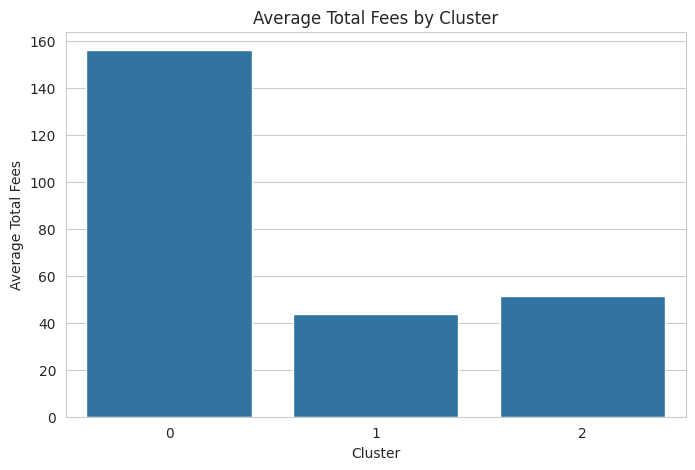

In [ ]:
#Phân tích theo Cluster
cluster_profit = customer_df.groupby("Cluster")[[
    "Total_Fees",
    "Total_Transaction_Amount",
    "High_profit_customer"
]].mean().sort_values(by="Total_Fees", ascending=False)

print("=== PHÂN TÍCH LỢI NHUẬN THEO CLUSTER ===")
print(cluster_profit)

plt.figure(figsize=(8,5))
sns.barplot(x=cluster_profit.index, y=cluster_profit["Total_Fees"])
plt.title("Average Total Fees by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Total Fees")
plt.show()

Kết quả phân tích theo cụm cho thấy Cluster 0 là nhóm có giá trị vượt trội về cả tổng phí (156,02 EUR), tổng giá trị giao dịch (22.140 EUR) và tỷ lệ khách hàng sinh lời cao (83,87%). Điều này xác nhận đây là phân khúc khách hàng cốt lõi, đóng góp phần lớn doanh thu và lợi nhuận cho ngân hàng. Trong khi đó, Cluster 1 và Cluster 2 có mức tổng phí và tỷ lệ sinh lời thấp hơn đáng kể (khoảng 33–39%). Đây có thể là các nhóm khách hàng tiềm năng nhưng chưa khai thác hết giá trị hoặc có mức độ sử dụng dịch vụ hạn chế.

=== PHẦN TRĂM KHÁCH HÀNG CÓ PHÍ PHẠT THEO CLUSTER ===
Cluster
0    61.303803
1    22.050978
2    25.597874
Name: Has_Late_Payment, dtype: float64


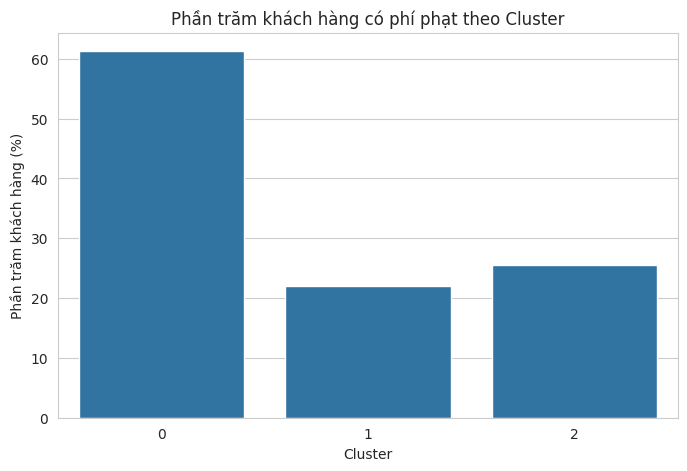

In [ ]:
#Nhóm nào tạo doanh thu từ phí phạt?
# The original code had a SyntaxError due to a colon after a boolean expression.
# Additionally, 'LatePaymentAmount' is not a direct column in the customer_df.
# We will analyze 'Has_Late_Payment' which is a customer-level indicator.

if "Has_Late_Payment" in customer_df.columns:
    penalty_cluster = customer_df.groupby("Cluster")["Has_Late_Payment"].mean() * 100

    print("=== PHẦN TRĂM KHÁCH HÀNG CÓ PHÍ PHẠT THEO CLUSTER ===")
    print(penalty_cluster)

    plt.figure(figsize=(8,5))
    sns.barplot(x=penalty_cluster.index, y=penalty_cluster.values)
    plt.title("Phần trăm khách hàng có phí phạt theo Cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Phần trăm khách hàng (%)")
    plt.show()
else:
    print("Cột 'Has_Late_Payment' không tìm thấy trong dữ liệu khách hàng.")

Phân tích tỷ lệ khách hàng có phí phạt (Has_Late_Payment) cho thấy Cluster 0 có tỷ lệ cao nhất (61,30%), cao hơn nhiều so với Cluster 1 (22,05%) và Cluster 2 (25,60%). Điều này cho thấy một phần đáng kể của lợi nhuận của nhóm sinh lợi cao có thể đến từ các khoản phí phạt hoặc phí trễ hạn.

Mặc dù điều này góp phần gia tăng doanh thu ngắn hạn, nhưng về dài hạn có thể tiềm ẩn rủi ro về hình ảnh thương hiệu và khả năng duy trì khách hàng. Do đó, ngân hàng cần cân nhắc chiến lược quản trị rủi ro và chính sách phí phù hợp nhằm đảm bảo tính bền vững.

=== TỶ LỆ SỬ DỤNG KÊNH THEO NHÓM LỢI NHUẬN ===
                      Pct_Mobile   Pct_ATM  Pct_Branch  Pct_Online
High_profit_customer                                              
0                       0.259000  0.243965    0.242549    0.254486
1                       0.261073  0.238408    0.260182    0.240336


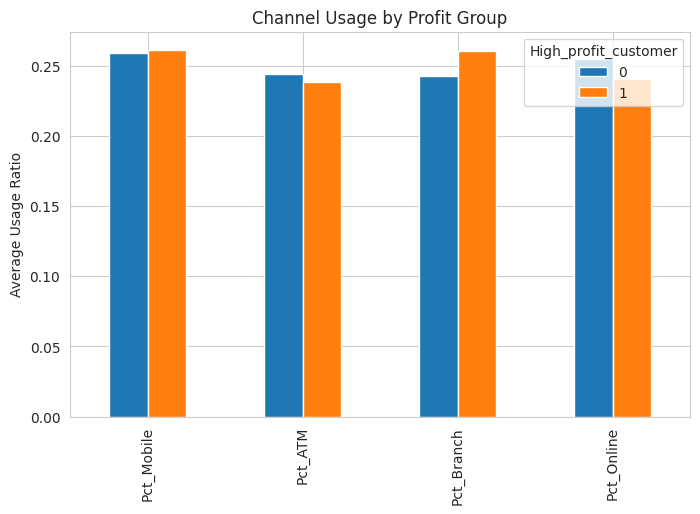

In [ ]:
#Kênh giao dịch nào hiệu quả nhất?
channel_effectiveness = customer_df.groupby("High_profit_customer")[[
    "Pct_Mobile",
    "Pct_ATM",
    "Pct_Branch",
    "Pct_Online"
]].mean()

print("=== TỶ LỆ SỬ DỤNG KÊNH THEO NHÓM LỢI NHUẬN ===")
print(channel_effectiveness)

channel_effectiveness.T.plot(kind="bar", figsize=(8,5))
plt.title("Channel Usage by Profit Group")
plt.ylabel("Average Usage Ratio")
plt.show()

Kết quả phân tích tỷ lệ sử dụng kênh giao dịch giữa hai nhóm lợi nhuận cho thấy sự khác biệt không quá lớn. Nhóm sinh lời cao có tỷ lệ sử dụng Mobile và Branch nhỉnh hơn nhẹ, trong khi nhóm còn lại sử dụng Online và ATM tương đối đồng đều.

Điều này hàm ý rằng kênh giao dịch không phải là yếu tố quyết định trực tiếp đến lợi nhuận, mà lợi nhuận phụ thuộc nhiều hơn vào cường độ và giá trị giao dịch. Tuy nhiên, việc tối ưu hóa trải nghiệm trên các kênh số vẫn có ý nghĩa chiến lược nhằm gia tăng tần suất giao dịch trong tương lai.

In [ ]:
#Cluster nào có rủi ro tiềm ẩn?
risk_analysis = customer_df.groupby("Cluster")[[
    "CustomerScore",
    "Total_Transaction_Amount"
]].mean()

print("=== PHÂN TÍCH RỦI RO THEO CLUSTER ===")
print(risk_analysis)

=== PHÂN TÍCH RỦI RO THEO CLUSTER ===
         CustomerScore  Total_Transaction_Amount
Cluster                                         
0           578.365650              22140.347883
1           575.518672               7887.785741
2           572.926041               9482.666420


Về khía cạnh rủi ro, Cluster 2 có điểm tín dụng trung bình thấp nhất (572,93), trong khi quy mô giao dịch ở mức trung bình (9.483 EUR). Đây có thể là nhóm khách hàng tiềm ẩn rủi ro nếu ngân hàng mở rộng tín dụng hoặc cung cấp sản phẩm tài chính phức tạp. Ngược lại, Cluster 0 tuy có tỷ lệ phí phạt cao nhưng điểm tín dụng trung bình lại cao nhất (578,37) và quy mô giao dịch lớn nhất. Điều này cho thấy đây là nhóm khách hàng vừa có giá trị cao vừa có mức độ an toàn tương đối tốt, song cần kiểm soát hành vi trễ hạn.

#### Liên hệ thực tiễn và Khuyến nghị chiến lược

Dựa trên kết quả phân cụm và mô hình phân loại khách hàng có khả năng sinh lời cao, chúng ta có thể đưa ra một số phân tích và khuyến nghị chiến lược cho ngân hàng.

In [ ]:
# Tóm tắt đặc điểm các cụm khách hàng đã được gán nhãn
print("\n--- TÓM TẮT ĐẶC ĐIỂM CÁC CỤM KHÁCH HÀNG ---")
for c, label in cluster_labels.items():
    print(f"Cluster {c} ({label}):")
    row = cluster_summary[cluster_summary['Cluster'] == c].iloc[0]
    print(f"  Số lượng khách hàng: {int(row['So_luong_khach'])}")
    print(f"  Tổng phí trung bình: {row['Tong_phi_trung_binh']:.2f} EUR")
    print(f"  Tổng tiền giao dịch trung bình: {row['Tong_tien_trung_binh']:.2f} EUR")
    print(f"  Tần suất giao dịch trung bình: {row['Tan_suat_trung_binh']:.2f}")
    print(f"  Điểm tín dụng trung bình: {row['Diem_tin_dung_trung_binh']:.0f}")
    print(f"  Thu nhập trung bình: {row['Thu_nhap_trung_binh']:.2f} EUR")
    print(f"  Tỷ lệ khách hàng có phí phạt: {row['Ty_le_co_phai_tre']:.2%} ")
    print(f"  Tỷ lệ sử dụng kênh Mobile: {row['Ty_le_Mobile']:.2%} ")
    print(f"  Tỷ lệ sử dụng kênh Branch: {row['Ty_le_Branch']:.2%} ")
    print("--------------------------------------------------")

print("\n--- KHUYẾN NGHỊ CHIẾN LƯỢC ---\n")

print("1. Đối với 'Cụm sinh lợi cao (giá trị lớn, tần suất cao)' (Cluster 0):")
print("   - **Đặc điểm:** Khách hàng có tổng phí cao nhất, tổng giá trị giao dịch và tần suất giao dịch cao nhất. Tuy nhiên, cũng có tỷ lệ khách hàng có phí phạt cao nhất. ")
print("   - **Khuyến nghị:** ")
print("     - **Chính sách giữ chân:** Đây là nhóm khách hàng giá trị nhất. Cần có các chương trình khách hàng thân thiết, ưu đãi đặc biệt hoặc dịch vụ chăm sóc khách hàng cao cấp để đảm bảo họ không chuyển sang đối thủ cạnh tranh.")
print("     - **Quản lý rủi ro phí phạt:** Do tỷ lệ phí phạt cao, cần chủ động liên hệ, nhắc nhở hoặc cung cấp các gói vay linh hoạt để giúp họ tránh các khoản phí không mong muốn, từ đó nâng cao sự hài lòng và giữ chân khách hàng.")
print("     - **Gia tăng sản phẩm chéo:** Đề xuất các sản phẩm/dịch vụ bổ sung phù hợp với nhu cầu của họ, ví dụ: tư vấn đầu tư, bảo hiểm, thẻ tín dụng cao cấp.")

print("\n2. Đối với 'Cụm truyền thống (branch/online)' (Cluster 1):")
print("   - **Đặc điểm:** Tần suất giao dịch và tổng giá trị giao dịch ở mức thấp nhất, sử dụng kênh truyền thống (Branch/Online) nhiều nhất, và tỷ lệ phí phạt thấp. ")
print("   - **Khuyến nghị:** ")
print("     - **Thúc đẩy giao dịch:** Khuyến khích họ tăng tần suất và giá trị giao dịch thông qua các ưu đãi cho giao dịch lớn, hoặc các chương trình tích điểm khi sử dụng dịch vụ.")
print("     - **Chuyển đổi kênh:** Cung cấp lợi ích rõ ràng khi chuyển sang kênh Mobile hoặc Online để tiết kiệm chi phí vận hành cho ngân hàng và gia tăng tiện ích cho khách hàng.")
print("     - **Cá nhân hóa ưu đãi:** Dựa vào lịch sử giao dịch để đưa ra các đề xuất sản phẩm tài chính nhỏ, phù hợp với nhu cầu và khả năng tài chính của họ.")

print("\n3. Đối với 'Cụm thiên về Mobile' (Cluster 2):")
print("   - **Đặc điểm:** Tổng phí và tổng giá trị giao dịch trung bình, tần suất giao dịch ở mức trung bình, nhưng có tỷ lệ sử dụng kênh Mobile cao nhất. ")
print("   - **Khuyến nghị:** ")
print("     - **Tối ưu hóa trải nghiệm Mobile:** Tiếp tục đầu tư vào ứng dụng di động, cải thiện tính năng, độ ổn định và bảo mật để duy trì sự hài lòng của nhóm khách hàng này.")
print("     - **Marketing qua kênh Mobile:** Sử dụng các thông báo đẩy (push notification) cá nhân hóa để quảng bá sản phẩm, dịch vụ mới hoặc các chương trình khuyến mãi.")
print("     - **Phát triển sản phẩm số:** Tập trung phát triển các sản phẩm, dịch vụ được thiết kế riêng cho người dùng di động, ví dụ: vay tiêu dùng nhanh qua app, tiết kiệm online linh hoạt.")

print("\n--- ÁP DỤNG MÔ HÌNH DỰ ĐOÁN KHÁCH HÀNG SINH LỜI CAO ---\n")
print(f"Mô hình tốt nhất được chọn là: {best_model_recall}")
print("   - **Mục tiêu:** Xác định sớm các khách hàng tiềm năng có khả năng trở thành 'High_profit_customer' hoặc nguy cơ rời đi đối với 'High_profit_customer' hiện tại.")
print("   - **Ứng dụng:** ")
print("     - **Marketing mục tiêu:** Tập trung các chiến dịch quảng cáo và bán hàng chéo vào những khách hàng được dự đoán có khả năng sinh lời cao để tối đa hóa hiệu quả.")
print("     - **Phòng ngừa rời bỏ:** Đối với những khách hàng hiện tại đang sinh lời cao nhưng có dấu hiệu thay đổi hành vi (dự đoán không còn sinh lời cao trong tương lai), ngân hàng có thể chủ động đưa ra các ưu đãi giữ chân.")
print("     - **Tối ưu hóa nguồn lực:** Phân bổ nguồn lực chăm sóc khách hàng và marketing một cách hiệu quả hơn, tập trung vào những đối tượng mang lại giá trị cao nhất.")



--- TÓM TẮT ĐẶC ĐIỂM CÁC CỤM KHÁCH HÀNG ---
Cluster 0 (Cụm sinh lợi cao (giá trị lớn, tần suất cao)):
  Số lượng khách hàng: 2393
  Tổng phí trung bình: 156.02 EUR
  Tổng tiền giao dịch trung bình: 22140.35 EUR
  Tần suất giao dịch trung bình: 4.07
  Điểm tín dụng trung bình: 578
  Thu nhập trung bình: 5444.25 EUR
  Tỷ lệ khách hàng có phí phạt: 61.30% 
  Tỷ lệ sử dụng kênh Mobile: 23.97% 
  Tỷ lệ sử dụng kênh Branch: 26.10% 
--------------------------------------------------
Cluster 1 (Cụm truyền thống (branch/online)):
  Số lượng khách hàng: 3374
  Tổng phí trung bình: 43.72 EUR
  Tổng tiền giao dịch trung bình: 7887.79 EUR
  Tần suất giao dịch trung bình: 1.66
  Điểm tín dụng trung bình: 576
  Thu nhập trung bình: 5415.54 EUR
  Tỷ lệ khách hàng có phí phạt: 22.05% 
  Tỷ lệ sử dụng kênh Mobile: 0.06% 
  Tỷ lệ sử dụng kênh Branch: 34.15% 
--------------------------------------------------
Cluster 2 (Cụm thiên về Mobile):
  Số lượng khách hàng: 2258
  Tổng phí trung bình: 51.51 EUR
  